# MINLP-Search — results explorer

**What this notebook is.** An interactive companion to the experiment framework. It explains what
was built, shows what has been verified, and renders every result as a figure you can export for an
article. Nothing here recomputes experiments — it reads the results that the studies already wrote
to disk.

**How to use it.** Run all cells top to bottom, then drive the widgets. Every section starts with a
short explanation of what you are looking at and why it matters.

**Contents**

| section | question it answers |
|---|---|
| 0. The problem | what is being tested, and what counts as a good answer |
| 0.3 Testing methodology | how a study is specified, executed, scored and analysed |
| 1. Priorities | what a "priority" is, what they look like, and how much of the data they allow |
| 2. What has been run | which studies exist, what they contain, and whether they are complete |
| 3. Badania I | are the hyperparameters justified, and what does more quality cost |
| 4. Badania II | what affects the method (data size, noise, feature type, strictness …) |
| 5. Badania III | how does it compare with established counterfactual methods |
| 6. Figure export | save any figure for the article |
| 7. Extending | how to add a new study, metric, dataset or priority set |


In [1]:
import sys, json, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

warnings.filterwarnings("ignore")
logging.disable(logging.INFO)          # the library logs each search stage at INFO

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "explainit").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp._context import load_context
from explainit.experiments.continuous_minlp.priority_sets import PRIORITY_SETS, build_priorities
from explainit.experiments.continuous_minlp.priority_methods.methods import (
    compute_priority_score, max_attainable_priority,
)
from explainit.experiments.paper.common.registry import (
    RESULTS_ROOT, RunRegistry, current_run_ids,
)
from explainit.experiments.paper.common.runspec import expand_grid, load_study_config
from explainit.experiments.paper.common import stats

PAPER_DIR = PROJECT_ROOT / "explainit" / "experiments" / "paper"
FIGURES_DIR = PAPER_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.autolayout": True})
pd.set_option("display.width", 200)

_CTX, _STUDY = {}, {}

def ctx(dataset):
    """Dataset + trained model, cached."""
    if dataset not in _CTX:
        _CTX[dataset] = load_context(dataset)
    return _CTX[dataset]

def study(name, stale=False):
    """Per-counterfactual rows of a study, restricted to the current config."""
    key = (name, stale)
    if key not in _STUDY:
        reg = RunRegistry(name)
        ids = None if stale else current_run_ids(name)
        _STUDY[key] = reg.load_counterfactuals(run_ids=ids)
    return _STUDY[key]

def available_studies():
    return sorted(p.name for p in RESULTS_ROOT.glob("*") if (p / "index.csv").exists())

def base_datasets():
    """Datasets with a priority set and a trained model, excluding factor variants."""
    out = []
    for key in sorted(PRIORITY_SETS):
        if "__" in key:
            continue
        if (PROJECT_ROOT / "explainit/experiments/continuous_minlp/models" / key / "model.keras").exists():
            out.append(key)
    return out

def save_fig(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"saved {path}")
    return path

print("datasets with priorities:", base_datasets())
print("studies on disk:", available_studies())

datasets with priorities: ['auto_mpg', 'bike_sharing_hourly', 'brazilian_houses_to_rent', 'carseats', 'diabetes', 'diamonds', 'insurance_charges']
studies on disk: ['method_diagnosis', 'smoke', 'step2_validation', 'study1_hyperparams', 'study2_factors', 'study3_comparison']


## 0. The problem being tested

We have a trained regression model and one instance — say a car whose predicted fuel consumption is
0.62 on a normalised scale. We want a **counterfactual**: a modified instance whose prediction hits a
requested **target** (say 0.43) within a tolerance `ε = 0.05`.

What makes this project different from classical counterfactual search is the second objective.
Every feature carries a user-declared **priority function** — a curve saying how acceptable each
value is *for this user*. The method must hit the target **and** maximise the sum of those
priorities, called the **priority score**.

So each attempt is judged on three things:

| | meaning |
|---|---|
| **validity** | did the counterfactual actually reach the target band |
| **normalised priority** | priority achieved ÷ best priority attainable in the allowed region — the main quality metric, comparable across datasets |
| **model rows** | how many instances the method sent to the model — the main cost metric, hardware independent |

Everything in this notebook is expressed in those three terms.

## 0.1 Reading guide — values, columns and statistics

This is a glossary for the short labels in the widgets, plots and tables. A **counterfactual (CF)**
is one proposed modified instance. An **attempt** is one method trying to make one CF for one
sample and seed. A table may average many attempts; `avg_` means that average at the run level.

| label | plain-language meaning | how to read it |
|---|---|---|
| `prediction`, `target` | the model output of a CF and the requested output | targets and predictions are scaled to 0–1; lower is not inherently better |
| `epsilon` / `ε` | permitted absolute prediction error | `0.05` means the prediction must lie within 0.05 of the target |
| `validity` | whether `abs(prediction - target) <= epsilon` | 1 / `True` is valid; a validity mean is the fraction of attempts that succeeded |
| `priority_score` | sum of the per-feature desirability values | higher is better, but raw scores depend on the number and type of features |
| `priority_score_normalised` / `priority` | `priority_score` divided by the best score attainable in that instance's allowed region | the primary quality measure; 1.0 is the attainable optimum and higher is better |
| `model_rows` | total rows passed to the predictive model | main compute-cost measure; lower is cheaper; it is a count, not elapsed time |
| `time_seconds`, `time_s` | elapsed wall-clock time | secondary cost measure; it depends on hardware |
| `l1` | sum of absolute feature changes from the original instance | proximity measure; lower means a smaller overall edit |
| `l2` | Euclidean length of the feature-change vector | another proximity measure; lower is a smaller edit |
| `n_changed`, `sparsity_fraction` | number / fraction of logical features changed | lower means the CF changes fewer features; a one-hot group counts as one logical categorical feature |
| `n`, `n_samples`, `n_cfs`, `n_cfs_valid`, `n_valid` | number of rows, selected source instances, requested CFs per instance, valid CFs, and valid rows used for a quality average | do not compare a priority mean without also checking `n_valid` and validity |
| `error = budget_exceeded`, `budget_fail` | the method reached its model-evaluation cap before completing | a failure rate of 0.20 means 20% of attempts exceeded the budget |
| `cf_source` | where the returned CF came from | `optimiser` is a search result; `anchor` is the Stage 1 reference point; `peak_lock_in` means the post-processing sweep improved it |
| `exemplar_source` | how Stage 1 found the anchor | `dataset_priority_filtered` means a real eligible training row; `random_in_range` means a generated point because no suitable row was found |
| `warm_start_best_model_gap` | real-model target error at the LP warm start | compare it with `epsilon`; a gap above epsilon exposes an inaccurate local surrogate |

**How the inferential tables work.** `delta` or `delta_vs_ref` is **variant/method A minus the
baseline/reference** on the same instance, so a negative priority delta means A is worse. `n_pairs`
or `pairs` is the number of matched instance-and-seed comparisons. `wins` / `losses` count paired
instances where A had higher / lower priority. `ci_low` and `ci_high` are the 95% bootstrap confidence
interval for the mean delta. `wilcoxon_p` is the paired Wilcoxon signed-rank p-value; `p_holm` is that
p-value after Holm correction for multiple comparisons. `alpha` is the chosen significance threshold
(usually 0.05). `cliffs_delta` is an effect size from −1 to +1: sign gives direction and magnitude
(`negligible`, `small`, `medium`, `large`) gives practical size. Statistical significance is evidence
about a difference, not proof that it is large or scientifically important.

## 0.2 Reading guide — settings, studies and encoded names

**Common run settings.** `seed` is the random-number seed; seeds 0, 1 and 2 repeat the same cell
under different controlled randomness. `n_samples` is the number of original test instances selected
for an arm. `n_cfs` is the number of requested alternatives per original instance (1 here).
`target_offset_pred_std = -1.0` asks for a prediction one model-output standard deviation lower than
the original; `-2.0` is the harder target. `target_offset` is the same idea in absolute normalised
prediction units. `skip_if_target_below` avoids impossible requests below the specified scale limit.

### 0.2a Worked example — what `shap_num_samples` actually means

The sentence below compresses several ideas. This subsection unpacks them in the exact order the
method uses them:
1. choose two points between which the prediction change will be explained;
2. estimate Shapley contributions of the features;
3. turn those contributions into linear coefficients;
4. use that linear model as the local surrogate that guides the search.

#### Step 1. What two points are being compared?

For the numerical part of the method, Shapley values are computed between:
- the **sample** being explained, call it `x`;
- the **target exemplar / anchor**, call it `z`.

Think of `x` as "where we start" and `z` as "a reference point in the allowed region". The model has
some prediction at `x` and another at `z`. Shapley values answer this question:
**how much of the prediction difference `f(z) - f(x)` should be attributed to each feature?**

#### Step 2. What is a "sampled Shapley permutation"?

A **permutation** is just an ordering of the features, for example `(feature 2, feature 1, feature 3)`
or `(feature 3, feature 1, feature 2)`. For one chosen ordering, we start from `x` and then replace
features one by one with their values from `z`. Each time a feature is inserted, we record how much
the model prediction changed. That change is that feature's contribution **for this one ordering**.

Because feature interactions exist, the contribution depends on the order. Shapley values average over
many orders so that no feature is always credited first or last.

#### Step 3. Tiny numerical example with 3 features

Suppose the true model is
$$
f(x_1, x_2, x_3) = 0.30 + 0.20x_1 + 0.10x_2 + 0.05x_3 + 0.10x_1x_2
$$

and suppose:
- sample `x = (0, 0, 0)` so `f(x) = 0.30`;
- anchor `z = (1, 1, 1)` so `f(z) = 0.75`.

The total prediction increase from `x` to `z` is therefore
$$
f(z) - f(x) = 0.75 - 0.30 = 0.45.
$$

Now take one permutation, say `(x_1, x_2, x_3)`:
1. start at `(0,0,0)` with prediction `0.30`;
2. insert `x_1`: go to `(1,0,0)`, prediction becomes `0.50`, so contribution of `x_1` is `+0.20`;
3. insert `x_2`: go to `(1,1,0)`, prediction becomes `0.70`, so contribution of `x_2` is `+0.20`;
4. insert `x_3`: go to `(1,1,1)`, prediction becomes `0.75`, so contribution of `x_3` is `+0.05`.

For that one permutation, the contributions are therefore `(0.20, 0.20, 0.05)`, and they sum to
`0.45`, exactly the total change.

But for a different permutation, for example `(x_2, x_1, x_3)`, the contributions change:
1. start at `(0,0,0)` with `0.30`;
2. insert `x_2`: `(0,1,0)` gives `0.40`, so contribution of `x_2` is `+0.10`;
3. insert `x_1`: `(1,1,0)` gives `0.70`, so contribution of `x_1` is now `+0.30`;
4. insert `x_3`: `(1,1,1)` gives `0.75`, so contribution of `x_3` is `+0.05`.

Now the same total `0.45` is split as `(0.30, 0.10, 0.05)`. The difference comes from the interaction
term `0.10 x_1 x_2`: whichever of `x_1` or `x_2` enters second gets credited for the interaction gain.

#### Step 4. Exact Shapley versus sampled Shapley

With 3 features there are `3! = 6` permutations. If we average over all 6, the exact Shapley values are:
- `phi_1 = 0.25`
- `phi_2 = 0.15`
- `phi_3 = 0.05`

These sum to `0.45`, the full prediction change.

Now suppose we do **not** average over all 6 orders. Suppose we sample only 3 random permutations:
- `(x_1, x_2, x_3)` -> contributions `(0.20, 0.20, 0.05)`
- `(x_2, x_3, x_1)` -> contributions `(0.30, 0.10, 0.05)`
- `(x_3, x_2, x_1)` -> contributions `(0.30, 0.10, 0.05)`

Averaging only these sampled permutations gives the approximate Shapley values:
- `phi_1 ≈ (0.20 + 0.30 + 0.30) / 3 = 0.2667`
- `phi_2 ≈ (0.20 + 0.10 + 0.10) / 3 = 0.1333`
- `phi_3 = (0.05 + 0.05 + 0.05) / 3 = 0.05`

These are close to the exact values `(0.25, 0.15, 0.05)`, but not identical, because we sampled only
3 orders instead of all 6.

This is exactly what `shap_num_samples` controls:
- `shap_num_samples = 3` means average over 3 sampled permutations;
- `shap_num_samples = 100` means average over 100 sampled permutations;
- `shap_num_samples = 800` means average over 800 sampled permutations.

More samples usually reduce Monte Carlo noise, because the average is taken over more random feature
orders. But more samples also mean more model evaluations.

#### Step 5. Why sample at all?

Because the number of permutations explodes. If there are 10 logical feature units, then there are
$$
10! = 3,628,800
$$
possible feature orders. Averaging over all of them is too expensive, so the method samples only some
of them and uses their average as an approximation.

#### Step 6. How do these Shapley values become the local surrogate model?

The implementation then turns each Shapley value into a per-unit linear coefficient
$$
a_i = \frac{\phi_i}{z_i - x_i}.
$$

In the toy example, `x = (0,0,0)` and `z = (1,1,1)`, so `z_i - x_i = 1` for every feature. Therefore
the coefficients are simply:
- `a_1 = 0.25`
- `a_2 = 0.15`
- `a_3 = 0.05`

The local surrogate is then the linear approximation
$$
h(x') = f(x) + 0.25(x'_1 - x_1) + 0.15(x'_2 - x_2) + 0.05(x'_3 - x_3).
$$

Since here `x = (0,0,0)` and `f(x) = 0.30`, this becomes
$$
h(x') = 0.30 + 0.25x'_1 + 0.15x'_2 + 0.05x'_3.
$$

This `h(x')` is the **local surrogate model**: a cheap linear stand-in for the real predictive model
near the sample-anchor direction. The optimiser uses `h`, not the full neural network, to decide which
feature changes might reach the target while staying inside the priority constraints.

#### Step 7. How the surrogate is actually used

Suppose the target prediction is `0.60`. Starting from `0.30`, the search needs a predicted increase of
about `+0.30`. Using the surrogate, the method looks for feature values satisfying approximately
$$
0.25x'_1 + 0.15x'_2 + 0.05x'_3 \approx 0.30
$$
while also respecting feature bounds and priorities.

For example, `x' = (1.0, 0.33, 0.0)` gives
$$
h(x') = 0.30 + 0.25(1.0) + 0.15(0.33) + 0.05(0.0) \approx 0.60.
$$

If we check the **real** nonlinear model at that same point, we get
$$
f(1.0, 0.33, 0.0) = 0.30 + 0.20(1.0) + 0.10(0.33) + 0.10(1.0)(0.33) \approx 0.596,
$$
which is close. That is the purpose of the surrogate: not to be exact everywhere, but to be close
enough locally that it can guide the search efficiently.

#### Step 8. Connecting this back to `model_rows`

Every sampled permutation requires model evaluations at partially constructed points between `x` and
`z`. So increasing `shap_num_samples` directly increases how many candidate rows are sent through the
model. That is why `model_rows` grows almost linearly with `shap_num_samples` in the actual study runs.

In short:
- a **sampled Shapley permutation** is one random order in which features are switched from `x` to `z`;
- `shap_num_samples` is how many such random orders are averaged;
- the averaged Shapley values are converted into linear coefficients;
- those coefficients define the **local surrogate model** that the optimiser uses to search for a
  counterfactual.

**MINLP-Search settings.** `shap_approx` selects sampled rather than exact Shapley values, and
`shap_num_samples` is the number of sampled Shapley permutations used to build the local surrogate
model. More samples usually make that surrogate more faithful, but they also increase `model_rows`,
which is the notebook's main compute-cost counter: the total number of feature vectors scored by the
predictive model while producing one counterfactual. The counter does **not** care how many Python
function calls were made; it counts how many rows were evaluated. So if the method scores one batch of
50 candidate points, that adds **50** to `model_rows`, not 1. If it then scores 10 single candidates,
the total becomes **60 model_rows**. It goes up because every extra sampled permutation or refinement
step asks the model to score more points.

The arm called `shap_budget` is simply the study's name for the experimental condition that
**sweeps** `shap_num_samples` across several values. Here an **arm** means one named experiment
variant or condition inside a study, not part of the algorithm itself. A **sweep** means
"systematically try a list of values for one setting and compare the results". In `study1_hyperparams`,
the `shap_budget` arm sets `shap_num_samples` to `[50, 100, 200, 400, 800]`. That produces five
conditions to compare: the same method, same dataset, same priorities, but five different Shapley
sample budgets.

**Worked example from the actual runs.** For `auto_mpg`, `medium`, seed 0, the `shap_budget` arm gave
approximately these mean costs per counterfactual:
- `shap_num_samples = 50`  -> `model_rows = 7058.5`
- `shap_num_samples = 100` -> `model_rows = 14059.3`
- `shap_num_samples = 200` -> `model_rows = 28060.2`
- `shap_num_samples = 400` -> `model_rows = 56062.8`
- `shap_num_samples = 800` -> `model_rows = 112060.1`

So doubling `shap_num_samples` almost doubles `model_rows`. That is the connection: more Shapley
samples mean the method asks the model to score proportionally more candidate points while building and
refining its local approximation. `max_model_rows` is then a hard cap on that counter. If the run is
allowed at most 2,000 rows and the next batch would push the total above 2,000, the run stops and is
recorded as `budget_exceeded`.

`max_iterations` is the maximum number of surrogate-rebuild/refinement cycles;
its sweep is called `refinement_passes`. `patience` stops those cycles after that many non-improving
iterations. `target_exemplar_epsilon` is how close an anchor may be to the target during Stage 1;
it is studied as `exemplar_tolerance`.

#### 0.2b What Stage 7 is trying to do, in plain language

Stage 7 starts **after** the main search has already found a counterfactual that is valid under the
real model, meaning its prediction is inside the allowed target band. At that point the method asks a
second question: "can I make this valid counterfactual more desirable for the user without breaking
validity?"

That is what the notebook means by **moving features to their most preferred values while compensating
elsewhere**.

A simple toy picture: suppose the current valid counterfactual has:
- `income = 52` but the user's priority curve would most prefer `income = 60`;
- `hours = 39` and changing `hours` slightly is not very costly in priority terms.

If we move `income` from `52` to `60`, the prediction may drift too high and leave the target band.
So Stage 7 then looks for another feature it can adjust to cancel that prediction drift. For example,
it may increase `income` by `+8` but decrease `hours` by `-2`, so the prediction stays near the
target while the total priority score improves. That second change is the **compensation elsewhere**.

How does the method know where to try moving things? It does **not** launch a brand-new optimiser in
Stage 7. Instead it uses two pieces of information it already has from earlier stages:
- for each feature, the **priority peak**, meaning the value that gives that feature the highest
  priority score within its allowed range;
- the latest **Shapley-linear coefficients**, which say approximately how much the prediction changes
  when each feature moves a little.

So Stage 7 works more like a guided repair-and-improve procedure than like a full optimisation. For a
feature `i`, it first proposes: "what if I set this feature directly to its priority peak?" Using the
cached linear coefficient `c_i`, it estimates the prediction change from that move as
$$
\Delta h \approx c_i (\text{peak}_i - x_i).
$$

Then it asks: "which other feature could offset that change as cheaply as possible in priority terms?"
For another feature `j`, it uses the same linear approximation to solve a simple compensation rule
$$
x_j^{new} \approx x_j - \frac{\Delta h}{c_j}.
$$

So yes, Stage 7 does use an **approximation** first: it uses the Shapley-linear surrogate to propose
where the compensating feature should move. But it does **not** trust that approximation blindly.
After building that trial point, it runs the **real predictive model** on it. If the real prediction
is still in the target band and the total priority improved, the move is accepted. If not, the move is
rejected, or one small restoration correction is tried first.

Limits are respected in two ways. First, when Stage 7 proposes a new value for a feature, that value is
clipped back into the feature's allowed interval, so it cannot move outside the legal search bounds.
Second, even if the proposed values are within bounds, the method still checks the real model and keeps
the change only if the final prediction remains within `target ± epsilon`.

So Stage 7 is effectively:
1. pick a promising feature and move it toward its best priority value;
2. use the surrogate coefficients to guess how another feature should compensate;
3. clip both values to allowed bounds;
4. run the real model on the trial point;
5. keep the change only if validity and total priority both improve.

Why is this extra step needed at all? In principle, one may hope that the iterative Shapley-guided
optimisation already returns the best possible counterfactual. In practice, that earlier optimisation
mainly tries to find a point that reaches the target band under a local surrogate. Once it has such a
point, it may stop at a solution that is valid but not yet at the best positions of the priority
curves. Stage 7 exists because the earlier optimiser is strongest at **finding a feasible point**,
while Stage 7 is a cheap targeted clean-up step for **improving priority without losing feasibility**.
So this does not automatically mean the method is bad; it means the optimisation and the final
preference-polishing step have been separated on purpose.

So Stage 7 is not searching from scratch. It is doing local trades around an already valid answer:
make one feature more preferred, offset the prediction change with one or more other features, keep the
new point only if it is still in band and has higher priority than before.

#### 0.2c What are "passes" and what are "sweeps" here?

A **pass** belongs to the main refinement loop, not to Stage 7. One pass means one full round of:
1. compute / recompute the Shapley surrogate;
2. solve the warm-start linear problem;
3. run the nonlinear optimiser;
4. check the real model and keep or reject the candidate.

So `max_iterations = 10` means the main search may do at most 10 such passes for one sample.

A **sweep** in `peak_lock_in_max_sweeps` belongs specifically to Stage 7. One Stage 7 sweep means:
go once through the actionable features, ask for each feature whether moving it toward its priority
peak can be compensated by other features, and accept any improving valid moves that are found.

If at least one move was accepted in that sweep, Stage 7 may start another sweep because the first set
of accepted moves changed the current point and may make further improvements possible. So:
- sweep 1: scan all features once;
- sweep 2: scan them again from the updated point;
- sweep 3: one more full scan, and so on.

`peak_lock_in_max_sweeps` is just the cap on how many of those repeated full scans are allowed. If it
is 1, Stage 7 gets one chance to improve the point. If it is 3, it may make up to three full rounds
over the features. It stops earlier if a full sweep finds no improving valid move.

#### 0.2d Trust region and local radius

The local surrogate is only trustworthy **near the point where it was built**. If the optimiser takes
a huge step, the linear approximation may say "this point should hit the target", while the real neural
network says something very different.

A **trust region** is a rule that prevents such oversized jumps. Instead of allowing the optimiser to
move anywhere inside the full allowed box in one pass, it allows movement only inside a smaller local
box around the current point.

The **local radius** is the size of that smaller box. In this implementation it is defined as a
fraction of each feature's allowed span. For example, if:
- a feature is allowed to vary between `10` and `30`, its full span is `20`;
- `trust_region_init = 0.25`;
then in the current pass that feature may move by at most `0.25 * 20 = 5` units away from the current
value.

So if the current value is `18`, the optimiser may search only roughly in `[13, 23]` for that feature
during that pass, not the whole `[10, 30]`. That is what "local radius" means here: how far the method
trusts its linear surrogate to be useful in one pass.

#### 0.2e Residual correction

After one pass, the method has two numbers for the candidate it just tested:
- what the surrogate predicted, call it `h(x)`;
- what the real model predicted, call it `f(x)`.

Their difference is the **residual**. If the surrogate said `0.40` but the real model said `0.47`,
then the residual is `+0.07`. In plain language: the surrogate was too optimistic and undershot the
true prediction by `0.07`.

`residual_correction` means the next pass remembers that mismatch instead of ignoring it. The next
surrogate solve is re-aimed by that amount. In the example above, if the true target is `0.40`, then
the next pass does not ask the surrogate to hit `0.40` again; it asks the surrogate for roughly
`0.33`, because experience from the previous pass suggests the true model will end up about `0.07`
higher than the surrogate prediction.

So residual correction is a cheap bias-fix: it uses the error already measured in the previous pass to
recalibrate the next pass, without paying extra model calls.

#### 0.2f Restoration

Sometimes the optimiser finds a candidate that is **close** to valid but just outside the target band.
For example, if the target is `0.40` with `epsilon = 0.05`, then the valid band is `[0.35, 0.45]`. If
the candidate gets real prediction `0.48`, it is invalid, but only barely.

Without restoration, such a candidate would simply be discarded. With `restoration`, the method tries
a small corrective move to pull it back into the band while keeping as much of its priority gain as
possible. In plain language: "this candidate is almost good; instead of throwing it away, can I nudge
it a little so that the real model prediction falls back inside the band?"

The correction direction is based on the Shapley-derived coefficients already available from the pass.
So restoration is a repair step for near-misses, not a brand-new search. If it succeeds, the method
keeps a high-priority point that would otherwise have been lost.

**MINLP-Search settings.** `peak_lock_in` is Stage 7 post-processing: it tries moving features to
their most preferred values while compensating elsewhere to keep the prediction in the target band.
`peak_lock_in_ablation` compares it off versus on; `peak_lock_in_max_sweeps` limits repeated full
Stage 7 scans over the actionable features. `trust_region` with `trust_region_init` restricts an
update to a local radius so the linear surrogate is used only near where it was built. `residual_correction`
re-aims the next surrogate at the remaining real-model error measured in the previous pass. `restoration`
makes a feasibility-repair attempt when the candidate is just outside the true target band. `use_monte_carlo`
asks the random-search baseline to sample candidates rather than solve a deterministic optimisation.
`max_iterations` for that baseline is its maximum number of draws.

**Study names and arms.** `smoke` is a tiny end-to-end technical check, not scientific evidence.
`method_diagnosis` describes the shipped method and its failure modes. `step2_validation` is an
ablation of trust region, residual correction and restoration; `step2_full` enables all three, and
`step2_full_with_peak` additionally enables Stage 7. `study1_hyperparams` (Badania I) tunes one
setting at a time and reports cost versus quality. `study2_factors` (Badania II) changes one data or
preference property, retrains, then compares with the unchanged dataset. `study3_comparison` (Badania
III) compares MINLP with established CF methods. `base` means the default configuration; `ablation`
means a component is deliberately switched off/on to isolate its contribution.

**Study III regime suffixes.** No suffix is the free-budget run. `_budget2k` applies the common cap of
2,000 `model_rows`. `_hard_target` uses a target two prediction standard deviations lower and a common
50,000-row safety cap. `_cat` releases categorical one-hot columns for that baseline, then repairs the
result to a valid one-hot category. `cost vs quality` is therefore a scatter plot of mean normalised
priority (up is better) against mean model rows (right is more expensive); it is not a single combined
score or a claim that either axis alone decides the winner.

**Study II variant names.** A name has the form `<base_dataset>__<factor>_<level>`. The portion before
`__` is the original dataset; `s0` / `s1` after a variant level denote independently constructed
versions of that manipulation, used as a replication check. `n_features_0p5` means retain the top
50% of logical features ranked by permutation importance (one-hot groups stay together), not that the
dataset literally has 0.5 features. Other factor names are `train_size_0p5` / `0p25` / `0p10` (keep
that fraction of training rows), `feature_noise_0p10` / `0p25` / `0p50` (Gaussian noise in scaled
numeric inputs), `label_noise_0p05` / `0p10` / `0p20` (noise added to training targets),
`target_skew_low` / `high` (resample training targets toward low / high values), `numerical_only`
(remove categorical one-hot groups), and `strictness_loose` / `medium` / `strict` (same data, tighter
or looser allowable preference region). A `baseline` variant is the unmodified dataset.

## 0.3 Testing methodology — how the research framework works

This section describes the **experimental harness**, not the internals of MINLP-Search. It answers
the methodological questions a reader or reviewer should ask: what is held fixed, what is varied,
what constitutes one observation, how methods are compared fairly, and how the reported numbers are
made reproducible. The same harness is used for diagnosis, hyperparameter tuning, factor analysis
and method comparison; only the study configuration changes.

### A. Establish the task before running a method

1. **Prepare one prediction problem per dataset.** Numerical inputs are standard-scaled; categorical
inputs are one-hot encoded; the regression target is min-max scaled to `[0, 1]`. A Keras MLP is
trained once for each base dataset or Badania II variant. Scaling gives the common target tolerance
`epsilon = 0.05` the same interpretation across datasets. The experiment evaluates counterfactuals
against this trained predictive model, not against the original observed target.
2. **Declare a decision scenario and priorities before evaluation.** Each logical feature is classified
as actionable or pinned, and any allowed change receives a priority function. Priority set, target,
tolerance, number of requested CFs and source sample are task inputs, never selected separately for
one method. The priority section below documents the concrete declarations.
3. **Run a feasibility pre-flight check.** For each `(dataset, priority set, sample)` condition, the
allowed region is sampled and the smallest observed `abs(prediction - target)` is recorded, together
with coverage: the proportion of training rows satisfying all constraints. A target outside the
allowed region is a property of the stated preferences, not evidence that a CF algorithm failed.
This check is particularly important for the inherited diabetes priorities, whose joint coverage is
zero.

### B. Specify a study as a controlled grid

A study is a versioned YAML configuration with shared **defaults** and named **arms**. Defaults define
the task (datasets, priority sets, `epsilon`, requested CFs, selection rule and seeds). Each arm
names one method and can override those values or list parameter levels to sweep. The harness takes
the Cartesian product of dataset × priority set × parameter level × seed. One product element is a
**run**; its human-readable `cell` labels the parameter level and its hashed `run_id` includes every
field that could change the result. This makes a changed configuration a new result, rather than a
silent overwrite of an old one.

The default selection design uses 10 test instances chosen with a fixed selection seed. A target is
defined from the selected instance's **model prediction**, normally one standard deviation lower
(`target_offset_pred_std = -1.0`), rather than a fixed raw decrement. Thus the requested difficulty
scales with the model-output distribution of each dataset. Three run seeds (0, 1 and 2) repeat each
cell to expose stochastic variation. A single CF is requested per instance in the principal studies,
so one method cannot gain an advantage merely by returning more alternatives.

The four scientific designs are deliberately different but use this same grid mechanism:

| study | controlled comparison | what varies | what is held fixed |
|---|---|---|---|
| diagnosis | existing search, search plus Stage 7, random-search baseline | method arm | instances, target, priority set, tolerance, seeds |
| Badania I | one-factor-at-a-time hyperparameter sweep | one algorithm setting per arm | healthy datasets, medium priorities, all other settings |
| Badania II | rebuilt data variant against its own base dataset | exactly one data/preference property | preprocessing pipeline, task selection, seeds, method configuration |
| Badania III | MINLP against reference CF methods | method and budget/difficulty regime | same source instance, target, tolerance, priority-derived feasible region and requested CF count |

### C. Execute each run reproducibly and preserve the audit trail

For a run, the harness loads the configured dataset/model, selects the specified original instances,
constructs the priorities separately for every method, and invokes the selected CF adapter. The per-run
seed drives stochastic operations such as random anchors, sampled Shapley values and stochastic
baselines. A fresh priority dictionary is created for every method invocation: this prevents mutation
performed by one method from leaking into the feasible region of another method. This isolation is a
fairness requirement, not merely implementation hygiene.

Every method sees its predictions through a counting wrapper. It records `model_rows`, including direct
gradient-model calls where the adapter can observe them. `max_model_rows`, when set, is a hard
per-instance budget: exceeding it produces the explicit outcome `budget_exceeded` instead of allowing
a slow method to run indefinitely. Wall-clock time is retained, but model rows are the primary cost
unit because they are more comparable across machines.

Completed output is immutable under `paper/results/<study>/runs/<run_id>/`: `spec.json` records the
exact configuration; `samples.csv` records the chosen source instances and targets;
`counterfactuals.csv` records one scored row per requested CF; and `summary.json` plus `index.csv`
record run-level aggregates and completion time. Re-running a study resumes missing runs rather than
recomputing complete ones. If a YAML configuration changes, old runs remain on disk for auditability
but are classified as **stale** and excluded from the notebook's current-configuration analysis.

### D. Score every output with the same evaluator

The evaluator is method-independent. For every returned CF it recomputes the trained model's
prediction, checks validity against the original target band, checks the priority-derived constraints,
and calculates priority, normalised priority, `l1`, `l2`, number of changed logical features, model
rows and time. This is essential in Badania III: reference methods optimise proximity or diversity, not
priority, yet all are scored afterwards using the same priority function. A high-priority invalid CF
is not treated as a successful solution; priority summaries are explicitly calculated over valid CFs,
while validity is reported beside them.

For mixed data, the common feasible region is derived from the priority set: immutable features stay
at their source values and actionable numerical features share the same allowed bounds. The standard
baseline adapters initially keep one-hot categories pinned; the `_cat` sensitivity arms release them
and repair the returned vector to a valid one-hot state. That repair is intentionally reported as an
experimental condition because it can move a CF outside the target band. It is not hidden as a generic
post-processing step.

### E. Aggregate without hiding reliability failures

The raw unit is an attempt: one dataset, priority set, source sample, seed and arm/method. Run summaries
report the number of selected samples, produced CFs and valid CFs; validity is calculated as the
fraction of produced CFs in the target band. Quality, proximity and other CF properties are then
summarised over valid CFs only. Compute cost is averaged over all attempts, including failures, since
a method still consumes resources when it does not solve the task. Diagnostics additionally retain
whether the returned answer came from optimisation or an anchor, how the anchor was found, why a search
stopped and how inaccurate the warm start was. These provenance measures prevent a fallback point from
being mistaken for an optimiser success.

This creates a deliberate two-part interpretation: **validity asks whether the method solved the task**;
**normalised priority asks how good its solution was when it did**. Neither number is sufficient alone.
For example, a method can have excellent priority among the few cases it solves but poor validity, or
can always return the unchanged instance with small `l1` but zero validity.

### F. Make statistical comparisons on matched observations

For quality comparisons, each method/configuration is first reduced to its best valid CF per matching
key. In the present studies `n_cfs = 1`, so this reduction does not select among multiple alternatives,
but it keeps the procedure valid if a future arm requests more. Two conditions are then inner-joined on
`(dataset, priority_set, sample_id, seed)`. Only pairs where both conditions produced a valid scored CF
enter the priority comparison. This is why `n_pairs` can be lower than the total number of attempted
instances and why quality claims must always be read alongside each method's validity rate.

For each paired difference $d_i = value_{A,i} - value_{B,i}$, the framework reports the mean and median
difference, wins/losses/ties, a two-sided Wilcoxon signed-rank test, an exact two-sided sign test,
Cliff's delta, and a 95% percentile-bootstrap confidence interval for the mean difference. The bootstrap
uses 10,000 resamples with a fixed analysis seed. When several arms or factor levels are tested against
one reference, p-values are adjusted using Holm-Bonferroni within that comparison family. The result is
therefore a paired statement about the same tasks, not a comparison of unrelated method averages.

### G. Article-ready reporting checklist

For each reported result, state: (1) dataset/model and model quality; (2) priority scenario and
strictness; (3) target definition and `epsilon`; (4) selected-instance count and run seeds; (5) the
exact method configuration or budget; (6) validity, normalised priority and `model_rows` together;
(7) the paired sample size, delta, confidence interval, effect size and Holm-adjusted p-value for a
comparison; and (8) applicable threats to validity, especially infeasible priority regions, categorical
repair, budget dependence and variant-construction replication. This is enough for a reader to separate
a method effect from a changed task, an unreachable target or a difference in computational budget.

### How to understand the output

The table above is meant to separate **research progress** from **scientific conclusions**.

Read it in this order:

1. **Status** tells you whether the evidence-collection phase for that study is finished.
2. **Runs** tells you how much evidence was collected for the study's current design.
3. **Question** tells you what business or research decision that study informs.
4. **What this gives us** tells you why the finished study matters.
5. **Stale runs** should not be treated as missing work; they are old evidence kept for auditability after a design changed.

### What this means at management level

If the status table shows that Diagnosis, Study I, Study II and Study III are complete, then the project
already has evidence for four distinct decisions:

- whether the current method behaves credibly and where it breaks;
- which default hyperparameters are justified;
- how robust the method is to changes in data and preference structure;
- how it compares with external reference methods under fair conditions.

That means the programme is no longer in an early exploratory phase. It already has a **completed
experimental backbone**. The open task is mainly to interpret, communicate and prioritise the findings,
not to wonder whether the core experiments were ever run.

At the same time, the presence of stale runs means the work has been iterated and refined. That is a
good sign operationally, but it also means only the **current-configuration runs** should be used in
reporting or decision-making.

## 0.4 A simpler map of the whole experiment

> This section is a plain-language summary of the research design. It is meant to answer one question:
"> **what exactly was done, why was it done, and how were results judged?**

> The short version is: we built one common experimental framework, then used it for four purposes:
"> **diagnosis**, **Study I**, **Study II**, and **Study III**. In every case the task is the same:
"> generate a counterfactual that reaches the requested prediction target and is as good as possible
"> under the user-defined priority rules.

### 1. What the experiment is about

The project tests **MINLP-Search**, a counterfactual-generation method for regression models. The method
needs to solve two problems at once:

1. **Validity:** produce a counterfactual whose prediction reaches the requested target within tolerance.
2. **Preference quality:** among valid counterfactuals, prefer the one that best matches the user's
   priorities over feature changes.

So the experiment is not only asking *"can the method hit the target?"* but also *"if it does, how good
is the solution from the user's perspective?"*

The full research question was split into four parts:

| part | main question |
|---|---|
| Diagnosis | how does the method behave internally, where does it fail, and which stages help? |
| Study I | which hyperparameter settings are justified, and what quality-cost trade-off do they create? |
| Study II | how do data properties and preference strictness affect the method? |
| Study III | how does MINLP-Search compare with standard counterfactual methods? |

### 2. Common setup used across the experiment

Before comparing methods or settings, the framework fixes the prediction task and the evaluation rules.
This makes the studies comparable.

#### 2.1 Datasets and trained models

The framework uses public **regression datasets**. Each dataset is turned into a prediction problem in
the same way:

- numerical features are **standard-scaled**;
- categorical features are **one-hot encoded**;
- the regression target is **min-max scaled to `[0, 1]`**;
- one **Keras MLP** is trained for each base dataset or Study II dataset variant.

This scaling is important because it makes the same target tolerance meaningful across datasets. The
default tolerance is

$$
\epsilon = 0.05
$$

so a valid counterfactual must satisfy

$$
|\hat{y}_{CF} - y_{target}| \le \epsilon.
$$

The main datasets used in the studies are:

- **auto_mpg**: main benchmark, good model quality, mixed numerical/categorical structure.
- **carseats**: main benchmark, tighter search problem with fewer actionable numerical features.
- **bike_sharing_hourly**: prepared as a more combinatorial mixed-data case.
- **diabetes**: stress case with inherited hand-written priorities that are often infeasible.
- **insurance_charges**: prepared as a narrow-search-space case and used in diagnosis.

Some prepared datasets were intentionally **excluded from the main studies** because model quality was
too weak for meaningful counterfactual interpretation.

#### 2.2 What one experimental task looks like

For one run, the framework chooses:

- a dataset and its trained model;
- a priority set describing what feature changes are allowed or preferred;
- an original test instance to explain;
- a target prediction;
- a tolerance `epsilon`;
- a method and its configuration.

The target is usually defined relative to the model's own prediction on the chosen instance, typically
**one prediction standard deviation lower** than the original prediction. This keeps task difficulty
comparable across datasets.

#### 2.3 Priority sets define the actual decision problem

Each experiment is run under a **priority set**. A priority set says:

- which features are **actionable** and which are **pinned**;
- for actionable features, which values are desirable, acceptable, or forbidden;
- for categorical groups, which states are allowed or preferred.

This is crucial: the priority set does not merely score solutions after the fact. It defines the
**feasible region** of the search. Therefore a difficult or infeasible priority set changes the task
itself, not just the method's score.

#### 2.4 One common selection design

Most studies use the same basic sampling plan:

- **10 selected test instances** per experimental cell;
- **3 random seeds** (`0`, `1`, `2`) per cell;
- usually **1 requested counterfactual** per instance.

This means the same instances, targets and seeds are reused across methods whenever a comparison is
intended to be fair.

### 3. How results are measured

The framework measures performance at three levels: **before the method runs**, **for each returned
counterfactual**, and **after many runs are aggregated**.

#### 3.1 Before the method runs: feasibility pre-flight

Before interpreting a method's failure, the framework asks whether the task may be feasible at all.
For each `(dataset, priority set, sample)` condition it checks the allowed region and estimates whether
the requested target can be reached.

This prevents a wrong conclusion. If the target lies outside the allowed region, that is evidence about
the **preferences**, not evidence that the method is poor.

#### 3.2 For each returned counterfactual: common evaluator

Every method output is re-scored by the same evaluator. For each counterfactual it computes:

- **validity**: whether the target band was actually reached;
- **priority score** and **normalised priority**: how good the solution is under the priority rules;
- **proximity measures** such as `l1`, `l2`, and number of changed logical features;
- **cost measures** such as `model_rows` and wall-clock time.

The most important three summary quantities in this notebook are:

| metric | meaning | why it matters |
|---|---|---|
| validity | fraction of attempts that hit the target band | tells whether the method solved the task |
| normalised priority | achieved priority divided by the best attainable priority in the allowed region | compares solution quality across datasets |
| model_rows | number of rows sent to the predictive model | machine-independent compute cost |

The logic is deliberate:

- **validity** answers: did the method succeed?
- **normalised priority** answers: how good was the success?
- **model_rows** answers: what did that success cost?

#### 3.3 After aggregation: matched statistical comparison

When two methods or two settings are compared, the framework does not compare unrelated averages. It
first matches the same task instances across conditions using keys such as dataset, priority set, sample
and seed. Then it compares paired outcomes.

Reported paired statistics include:

- mean and median paired difference;
- wins, losses and ties;
- Wilcoxon signed-rank test;
- sign test;
- Cliff's delta;
- bootstrap confidence interval for the mean difference;
- Holm-adjusted p-values when multiple comparisons are made.

So every inferential claim is intended to mean: **on the same tasks, condition A performed better or
worse than condition B by this amount**.

### 4. How the whole research programme was organised

The same execution and scoring harness was reused in four parts. What changes from part to part is only
the scientific question.

### 4.1 Diagnosis

**Purpose.** Understand the method's internal behaviour before claiming scientific advantages.

**What was tested.** The shipped search procedure, important components such as later improvement stages,
and a random-search baseline.

**What was held fixed.** The framework keeps the same kind of target definition, tolerance, instance
selection and priority rules for the compared arms.

**What was measured.** In addition to the common metrics, diagnosis also keeps method-internal provenance
information, for example:

- whether the final answer came from optimisation or from an anchor/fallback;
- how the anchor was found;
- why the search stopped;
- how good the warm start was before the real-model check.

**What this stage is for.** Diagnosis is not mainly about publishing a winner. It is for checking where
the method spends cost, where it fails, and which components actually improve behaviour.

**Main conclusion.** The diagnosis stage establishes whether the full procedure behaves as intended and
which pieces are worth carrying into later studies.

### 4.2 Study I: hyperparameter study

**Purpose.** Test whether the default MINLP-Search settings are justified and identify the main
quality-versus-cost trade-offs.

**What was varied.** One hyperparameter at a time, for example the Shapley sampling budget, number of
refinement iterations, exemplar tolerance, and whether specific refinement components are enabled.

**What was held fixed.** Healthy benchmark datasets, priority setting, target construction, seeds, and
the rest of the method configuration.

**What was measured.** The study focuses on:

- validity;
- normalised priority;
- `model_rows`;
- proximity metrics;
- stability across seeds.

**How to read the result.** A setting is good only if any quality gain is worth its extra cost. So Study I
asks not just whether one parameter value is best, but whether it is **efficient**.

**Main conclusion.** Study I is used to justify the final default configuration: keep the components that
meaningfully improve quality or reliability, and avoid settings that cost much more while changing little.

### 4.3 Study II: factor study

**Purpose.** Test how the method reacts when the *problem itself* changes.

**What was varied.** Instead of changing the algorithm, this study changes one property of the dataset or
decision setup at a time. Examples include:

- fewer training rows;
- fewer features;
- feature noise;
- label noise;
- skewed target distribution;
- removal of categorical features;
- stricter or looser priority sets.

Each variant is rebuilt from a base dataset, retrained, and then evaluated under the same framework.

**What was held fixed.** The preprocessing logic, model family, selection design, seeds, and method
configuration remain fixed so that the observed effect can be attributed to the modified factor.

**What was measured.** The same core metrics are used, and the same analysis is run for both MINLP-Search
and a priority-weighted random-search baseline.

**Why include the baseline here.** If a factor hurts both methods, then the factor probably makes the task
itself harder. If it hurts MINLP much more than the baseline, then it is a method-specific weakness.

**Main conclusion.** Study II identifies which data and preference properties truly change method
behaviour, and which apparent effects are just consequences of making the task harder overall.

### 4.4 Study III: method comparison

**Purpose.** Compare MINLP-Search with established counterfactual-generation methods under a fair common
task definition.

**What was varied.** The method itself. The study compares MINLP-Search against several reference CF
methods, and repeats the comparison under different regimes such as:

- free budget;
- shared model-evaluation budget;
- harder targets;
- categorical-release sensitivity arms for baselines.

**What was held fixed.** For every matched comparison, methods receive the same:

- source instance;
- target and tolerance;
- number of requested counterfactuals;
- priority-derived feasible region.

**How fairness is enforced.** Even methods that do not optimise priority directly are scored afterwards
with the same evaluator and the same priority function.

**What was measured.** Study III emphasises:

- validity;
- normalised priority on valid counterfactuals;
- model_rows as the main cost measure;
- paired statistical differences against a reference method.

**Main conclusion.** Study III tells us not only whether MINLP-Search can produce better solutions, but
also under what budget and task conditions that advantage exists or disappears.

### 5. What the reader should take away

A simple way to read the whole experiment is:

1. **Diagnosis** asks whether the method's internal logic works and which components matter.
2. **Study I** asks how to set the method up sensibly.
3. **Study II** asks what kinds of data and preference structures help or hurt it.
4. **Study III** asks whether it is actually better than established alternatives on matched tasks.

Across all four parts, the framework keeps the same evaluation principle:

- define the task first;
- check feasibility before blaming a method;
- score every returned counterfactual in the same way;
- compare methods on matched observations;
- report quality together with reliability and cost.

That is the central logic of the experiment: **the method is never judged by one number alone**. It is
judged by whether it solves the task, how good the valid solution is, and how much computation was
required to obtain it.

## 0.4 Where the experiment stands today — business view

This section is a **status update**, not a method explanation. It answers four practical questions:

1. **What parts of the research programme have already been completed?**
2. **How much evidence has already been collected?**
3. **Which conclusions are already supported by finished runs?**
4. **What should be read as final evidence, and what should be read only as diagnostic work?**

The goal is to make the current state of the experiment readable without needing to decode YAML files,
method names, or notebook widgets.

### How to read the status below

- A **study** is one block of work with a specific question, for example tuning, robustness, or method comparison.
- A **run** is one fully specified experiment cell: one study arm, one dataset or variant, one priority setting, and one seed.
- **Complete** means all runs required by the current configuration already exist on disk.
- **Stale** means older runs from a previous version of a study configuration. They are kept for auditability, but they are **not** part of the current analysis.

So the key distinction is this:

- **current runs** = the evidence used by this notebook now;
- **stale runs** = historical artefacts kept for traceability, not for conclusions.

In [32]:
study_overview = {
    "method_diagnosis": {
        "phase": "Diagnosis",
        "question": "Does the current method work as intended, and where do failures come from?",
        "role": "Diagnostic evidence only — explains behaviour and failure modes before comparative claims.",
    },
    "step2_validation": {
        "phase": "Method validation",
        "question": "Do the proposed Step 2 repairs improve the core search enough to justify them?",
        "role": "Internal validation — checks candidate method improvements before broader rollout.",
    },
    "study1_hyperparams": {
        "phase": "Study I",
        "question": "Which MINLP settings are justified, and what quality-cost trade-off do they create?",
        "role": "Decision support for choosing the default configuration.",
    },
    "study2_factors": {
        "phase": "Study II",
        "question": "How sensitive is the method to changes in data quality, feature structure, and priority strictness?",
        "role": "Robustness evidence — tells us where the method is stable and where it is vulnerable.",
    },
    "study3_comparison": {
        "phase": "Study III",
        "question": "How does MINLP compare with established counterfactual methods under fair matched tasks?",
        "role": "External comparison — this is the main evidence for competitive performance.",
    },
}

def _status_label(row):
    if bool(row["complete"]):
        return "Complete"
    if int(row["runs_done"]) == 0:
        return "Not started"
    return "In progress"

def _business_state_view():
    df = state.copy().sort_values("study").reset_index(drop=True)
    total_expected = int(df["runs_expected"].sum())
    total_done = int(df["runs_done"].sum())
    total_stale = int(df["stale_runs"].sum())
    complete_n = int(df["complete"].sum())
    incomplete_n = int((~df["complete"]).sum())

    display(Markdown(
        f"### Executive summary\n"
        f"- **{total_done} of {total_expected} current-configuration runs are complete**.\n"
        f"- **{complete_n} of {len(df)} configured studies are complete**; **{incomplete_n}** are still in progress.\n"
        f"- **{total_stale} stale runs** remain on disk for traceability, but they are excluded from the current analysis."
    ))

    rows = []
    for _, row in df.iterrows():
        info = study_overview.get(row["study"], {})
        rows.append({
            "phase": info.get("phase", row["study"]),
            "study": row["study"],
            "status": _status_label(row),
            "runs": f"{int(row['runs_done'])}/{int(row['runs_expected'])}",
            "question": info.get("question", ""),
            "what_this_gives_us": info.get("role", ""),
            "stale_runs": int(row["stale_runs"]),
        })

    status_df = pd.DataFrame(rows)
    display(Markdown("### What has already been done"))
    display(status_df)

    completed = status_df[status_df["status"] == "Complete"]
    if not completed.empty:
        done_lines = [
            f"- **{r.phase}**: finished ({r.runs} runs). {r.what_this_gives_us}"
            for r in completed.itertuples(index=False)
        ]
        display(Markdown("### What the team can already say\n" + "\n".join(done_lines)))

    if total_stale > 0:
        stale_df = df.loc[df["stale_runs"] > 0, ["study", "stale_runs"]].copy()
        stale_df = stale_df.sort_values("stale_runs", ascending=False)
        display(Markdown(
            "### Audit trail note\n"
            "Stale runs are older results produced under previous study configurations. "
            "They are useful for traceability, but they should **not** be read as the current evidence base."
        ))
        display(stale_df)

_business_state_view()

### Executive summary
- **777 of 777 current-configuration runs are complete**.
- **5 of 5 configured studies are complete**; **0** are still in progress.
- **192 stale runs** remain on disk for traceability, but they are excluded from the current analysis.

### What has already been done

,phase,study,status,runs,question,what_this_gives_us,stale_runs
0,Diagnosis,method_diagnosis,Complete,99/99,"Does the current method work as intended, and ...",Diagnostic evidence only — explains behaviour ...,66
1,Method validation,step2_validation,Complete,42/42,Do the proposed Step 2 repairs improve the cor...,Internal validation — checks candidate method ...,0
2,Study I,study1_hyperparams,Complete,180/180,"Which MINLP settings are justified, and what q...",Decision support for choosing the default conf...,0
3,Study II,study2_factors,Complete,258/258,How sensitive is the method to changes in data...,Robustness evidence — tells us where the metho...,102
4,Study III,study3_comparison,Complete,198/198,How does MINLP compare with established counte...,External comparison — this is the main evidenc...,24


### What the team can already say
- **Diagnosis**: finished (99/99 runs). Diagnostic evidence only — explains behaviour and failure modes before comparative claims.
- **Method validation**: finished (42/42 runs). Internal validation — checks candidate method improvements before broader rollout.
- **Study I**: finished (180/180 runs). Decision support for choosing the default configuration.
- **Study II**: finished (258/258 runs). Robustness evidence — tells us where the method is stable and where it is vulnerable.
- **Study III**: finished (198/198 runs). External comparison — this is the main evidence for competitive performance.

### Audit trail note
Stale runs are older results produced under previous study configurations. They are useful for traceability, but they should **not** be read as the current evidence base.

,study,stale_runs
3,study2_factors,102
0,method_diagnosis,66
4,study3_comparison,24


## 0.4.1 Exactly what was verified — datasets, priority sets, factor values, and sample counts

This section is the **coverage map** of the experiment. Its purpose is simple: show exactly

- which datasets were verified,
- which priority sets were used on each dataset,
- which factors or comparison regimes were tested,
- which exact values were checked,
- and how many source samples were verified for each study and dataset.

### How to read the sample counts

The sample counts below use two different ideas, and they should not be confused:

1. **Source samples per configuration cell**
   This is how many original instances were selected for one experimental condition before repeating it over random seeds.
2. **Sample-level attempts**
   This is the number of evaluated source-instance attempts after seed repetition. If one configuration uses 10 source samples and 3 seeds, that becomes 30 sample-level attempts.

This distinction matters because the same selected source instances are often reused across seeds. So
**30 sample-level attempts does not necessarily mean 30 different source rows**. It means 10 source rows
were evaluated under 3 stochastic repeats.

The tables below therefore report both the **per-configuration sample count** and the **total attempt count** so the scope is clear.

In [37]:
from collections import defaultdict

_study_order = [
    "method_diagnosis",
    "step2_validation",
    "study1_hyperparams",
    "study2_factors",
    "study3_comparison",
]

_study_dirs = {
    "method_diagnosis": "study_method_diagnosis",
    "step2_validation": "study_step2_validation",
    "study1_hyperparams": "study1_hyperparams",
    "study2_factors": "study2_factors",
    "study3_comparison": "study3_comparison",
}

_phase_names = {
    "method_diagnosis": "Diagnosis",
    "step2_validation": "Method validation",
    "study1_hyperparams": "Study I",
    "study2_factors": "Study II",
    "study3_comparison": "Study III",
}

def _sample_count(selection):
    if selection.get("strategy") == "indices":
        return len(selection.get("sample_indices", []))
    return int(selection.get("n_samples", 0))

def _target_rule_parts(selection):
    if "target_offset_pred_std" in selection:
        return "prediction std", str(selection["target_offset_pred_std"])
    if "target_offset" in selection:
        return "scaled units", str(selection["target_offset"])
    return "custom", "—"

def _base_dataset(dataset_key):
    return str(dataset_key).split("__", 1)[0]

def _fmt_list(values):
    values = [str(v) for v in values if str(v)]
    return ", ".join(values) if values else "—"

def _fmt_int_set(values):
    values = sorted({int(v) for v in values})
    return "/".join(str(v) for v in values) if values else "—"

def _short_arm_summary(arms):
    arms = sorted(str(a) for a in arms)
    if len(arms) <= 3:
        return ", ".join(arms)
    return f"{arms[0]}, {arms[1]}, ... (+{len(arms) - 2} more)"

def _study_factor_table_rows():
    rows = []
    rows.extend([
        {"study": "Diagnosis", "factor": "method stage", "values_verified": "minlp_search_only; minlp_with_peak_lock_in; random_search_baseline"},
        {"study": "Diagnosis", "factor": "priority strictness on generic datasets", "values_verified": "loose, medium, strict"},
        {"study": "Method validation", "factor": "Step 2 controls", "values_verified": "baseline_no_step_control; trust_region_only (trust_region_init = 0.25); residual_correction_only; restoration_only; step2_full; step2_full_with_peak"},
        {"study": "Method validation", "factor": "reference baseline", "values_verified": "random_search_reference (max_iterations = 10000, use_monte_carlo = true)"},
        {"study": "Study I", "factor": "shap_num_samples", "values_verified": "50, 100, 200, 400, 800"},
        {"study": "Study I", "factor": "max_iterations", "values_verified": "1, 3, 5, 10, 20"},
        {"study": "Study I", "factor": "patience", "values_verified": "1, 3, 5, 10"},
        {"study": "Study I", "factor": "target_exemplar_epsilon", "values_verified": "0.05, 0.10, 0.20, 0.40"},
        {"study": "Study I", "factor": "shap_approx", "values_verified": "true, false"},
        {"study": "Study I", "factor": "peak_lock_in", "values_verified": "false, true"},
        {"study": "Study I", "factor": "peak_lock_in_max_sweeps", "values_verified": "1, 3, 6"},
        {"study": "Study I", "factor": "random_search baseline budget", "values_verified": "max_iterations = 1000, 5000, 10000"},
        {"study": "Study II", "factor": "train_size", "values_verified": "0p5, 0p25, 0p1"},
        {"study": "Study II", "factor": "n_features", "values_verified": "0p75, 0p5"},
        {"study": "Study II", "factor": "feature_noise", "values_verified": "0p1, 0p25, 0p5"},
        {"study": "Study II", "factor": "label_noise", "values_verified": "0p05, 0p1, 0p2"},
        {"study": "Study II", "factor": "target_skew", "values_verified": "low_heavy, high_heavy"},
        {"study": "Study II", "factor": "numerical_only", "values_verified": "True"},
        {"study": "Study II", "factor": "priority strictness", "values_verified": "loose, medium, strict"},
        {"study": "Study II", "factor": "replication variants", "values_verified": "numerical_only_True_s1; n_features_0p5_s1; label_noise_0p2_s1"},
        {"study": "Study III", "factor": "comparison regime", "values_verified": "free budget; budget2k (max_model_rows = 2000); categorical released (allow_categorical = true); hard_target (target_offset_pred_std = -2.0, max_model_rows = 50000)"},
        {"study": "Study III", "factor": "methods compared", "values_verified": "minlp; random_search; dice; wachter; sparse_wachter; prototype; growing_spheres; nelder_mead; bayesian_optimization"},
    ])
    return pd.DataFrame(rows)

def _build_scope_data():
    overview_rows = []
    dataset_rows = []

    for study_name in _study_order:
        cfg_path = PAPER_DIR / _study_dirs[study_name] / "config.yaml"
        cfg = load_study_config(cfg_path)
        specs = expand_grid(cfg)
        phase = _phase_names[study_name]
        sample_counts = sorted({_sample_count(spec.selection) for spec in specs})
        seed_values = sorted({spec.seed for spec in specs})
        datasets = sorted({spec.dataset for spec in specs})
        base_datasets = sorted({_base_dataset(spec.dataset) for spec in specs})
        priority_sets = sorted({spec.priority_set for spec in specs})
        per_config_attempts = sorted({_sample_count(spec.selection) * len(seed_values) for spec in specs})
        total_sample_attempts = sum(_sample_count(spec.selection) for spec in specs)
        target_bases = sorted({_target_rule_parts(spec.selection)[0] for spec in specs})
        target_shifts = sorted({_target_rule_parts(spec.selection)[1] for spec in specs})

        overview_rows.append({
            "study": phase,
            "datasets_verified": _fmt_list(base_datasets),
            "exact_dataset_keys": len(datasets),
            "priority_sets": _fmt_list(priority_sets),
            "source_samples_per_configuration": _fmt_int_set(sample_counts),
            "seed_repeats": _fmt_int_set(seed_values),
            "sample_attempts_per_configuration": _fmt_int_set(per_config_attempts),
            "run_cells": len(specs),
            "total_sample_attempts": int(total_sample_attempts),
            "target_basis": _fmt_list(target_bases),
            "target_shift": _fmt_list(target_shifts),
        })

        grouped = defaultdict(list)
        for spec in specs:
            grouped[spec.dataset].append(spec)

        for dataset_key, group in sorted(grouped.items()):
            base_dataset = _base_dataset(dataset_key)
            sample_per_cfg = sorted({_sample_count(spec.selection) for spec in group})
            seeds = sorted({spec.seed for spec in group})
            arms = sorted({spec.arm for spec in group})
            methods = sorted({spec.method for spec in group})
            config_units = {
                (spec.arm, spec.priority_set, spec.cell, json.dumps(spec.selection, sort_keys=True), spec.method)
                for spec in group
            }
            dataset_rows.append({
                "study": phase,
                "dataset_key": dataset_key,
                "base_dataset": base_dataset,
                "priority_sets": _fmt_list(sorted({spec.priority_set for spec in group})),
                "arm_count": len(arms),
                "methods": _fmt_list(methods),
                "arm_examples": _short_arm_summary(arms),
                "source_samples_per_configuration": _fmt_int_set(sample_per_cfg),
                "seed_repeats": _fmt_int_set(seeds),
                "configuration_cells": len(config_units),
                "run_cells": len(group),
                "total_sample_attempts": int(sum(_sample_count(spec.selection) for spec in group)),
                "all_arms": arms,
            })

    overview_df = pd.DataFrame(overview_rows)
    dataset_df = pd.DataFrame(dataset_rows)
    factor_df = _study_factor_table_rows()
    return overview_df, dataset_df, factor_df

def _arm_details_widget(dataset_df):
    study_options = list(dataset_df["study"].drop_duplicates())
    study_dd = widgets.Dropdown(options=study_options, description="study:")
    dataset_dd = widgets.Dropdown(description="dataset:")

    def _dataset_options(study):
        sub = dataset_df[dataset_df["study"] == study]
        return list(sub["dataset_key"].drop_duplicates())

    def _refresh_dataset_options(*_):
        dataset_dd.options = _dataset_options(study_dd.value)
        if dataset_dd.options and dataset_dd.value not in dataset_dd.options:
            dataset_dd.value = dataset_dd.options[0]

    study_dd.observe(_refresh_dataset_options, names="value")
    _refresh_dataset_options()

    def _show_details(study, dataset_key):
        sub = dataset_df[(dataset_df["study"] == study) & (dataset_df["dataset_key"] == dataset_key)]
        if sub.empty:
            print("no details")
            return
        row = sub.iloc[0]
        arms_df = pd.DataFrame({"arm_name": row["all_arms"]})
        display(Markdown(
            f"### Full arm list for `{study}` / `{dataset_key}`\n"
            f"- methods: **{row['methods']}**\n"
            f"- priority sets: **{row['priority_sets']}**\n"
            f"- arm count: **{row['arm_count']}**"
        ))
        display(arms_df)

    out = widgets.interactive_output(_show_details, {"study": study_dd, "dataset_key": dataset_dd})
    display(widgets.VBox([widgets.HBox([study_dd, dataset_dd]), out]))

def _verified_scope_tables():
    overview_df, dataset_df, factor_df = _build_scope_data()
    dataset_display_df = dataset_df.drop(columns=["all_arms"])

    display(Markdown(
        "### Coverage summary by study\n"
        "This table shows the scope of each completed study: which datasets it covered, which priority sets it used, and how many source-sample attempts it generated."
    ))
    display(overview_df)

    display(Markdown(
        "### Exact dataset verification list\n"
        "This table answers the literal question \"which dataset keys were verified in each study?\". "
        "The `arm_examples` column stays in the table for a quick overview, and the widget below shows the full untruncated arm names."
    ))
    display(dataset_display_df)

    display(Markdown(
        "### Full arm names for a selected dataset\n"
        "Use this selector when you want to inspect every arm name for one study and one dataset key without truncation."
    ))
    _arm_details_widget(dataset_df)

    display(Markdown(
        "### Exact factors and values that were checked\n"
        "This is the factor checklist for the completed programme: for each study, it lists the exact settings or levels that were deliberately verified."
    ))
    display(factor_df)

    display(Markdown(
        "### How to interpret the sample totals\n"
        "- `source_samples_per_configuration` is the number of original instances selected before seed repetition.\n"
        "- `seed_repeats` is how many stochastic repeats were run for the same configuration.\n"
        "- `sample_attempts_per_configuration` is therefore the typical verification workload per configuration cell.\n"
        "- `target_basis` says whether the target shift was defined in prediction standard deviations or in scaled units.\n"
        "- `target_shift` gives the actual shift value.\n"
        "- `arm_examples` gives a quick compact preview, and the widget below the table shows the complete arm list for the selected study/dataset pair."
    ))

_verified_scope_tables()

### Coverage summary by study
This table shows the scope of each completed study: which datasets it covered, which priority sets it used, and how many source-sample attempts it generated.

,study,datasets_verified,exact_dataset_keys,priority_sets,source_samples_per_configuration,seed_repeats,sample_attempts_per_configuration,run_cells,total_sample_attempts,target_basis,target_shift
0,Diagnosis,"auto_mpg, carseats, diabetes, insurance_charges",4,"loose, medium, set1, set2, strict",10,0/1/2,30,99,990,prediction std,-1.0
1,Method validation,diabetes,1,"set1, set2",10,0/1/2,30,42,420,scaled units,-0.3
2,Study I,"auto_mpg, carseats, diabetes",3,"medium, set1, set2",10,0/1/2,30,180,1800,prediction std,-1.0
3,Study II,"auto_mpg, bike_sharing_hourly, carseats",37,"loose, medium, strict",10,0/1/2,30,258,2580,prediction std,-1.0
4,Study III,"auto_mpg, bike_sharing_hourly, carseats",3,medium,10,0/1/2,30,198,1980,prediction std,"-1.0, -2.0"


### Exact dataset verification list
This table answers the literal question "which dataset keys were verified in each study?". The `arm_examples` column stays in the table for a quick overview, and the widget below shows the full untruncated arm names.

,study,dataset_key,base_dataset,priority_sets,arm_count,methods,arm_examples,source_samples_per_configuration,seed_repeats,configuration_cells,run_cells,total_sample_attempts
0,Diagnosis,auto_mpg,auto_mpg,"loose, medium, strict",3,"minlp, random_search","minlp_search_only_generic, minlp_with_peak_loc...",10,0/1/2,9,27,270
1,Diagnosis,carseats,carseats,"loose, medium, strict",3,"minlp, random_search","minlp_search_only_generic, minlp_with_peak_loc...",10,0/1/2,9,27,270
2,Diagnosis,diabetes,diabetes,"set1, set2",3,"minlp, random_search","minlp_search_only, minlp_with_peak_lock_in, ra...",10,0/1/2,6,18,180
3,Diagnosis,insurance_charges,insurance_charges,"loose, medium, strict",3,"minlp, random_search","minlp_search_only_generic, minlp_with_peak_loc...",10,0/1/2,9,27,270
4,Method validation,diabetes,diabetes,"set1, set2",7,"minlp, random_search","baseline_no_step_control, random_search_refere...",10,0/1/2,14,42,420
5,Study I,auto_mpg,auto_mpg,medium,9,"minlp, random_search","base, exact_vs_approx_shapley, ... (+7 more)",10,0/1/2,29,87,870
6,Study I,carseats,carseats,medium,9,"minlp, random_search","base, exact_vs_approx_shapley, ... (+7 more)",10,0/1/2,29,87,870
7,Study I,diabetes,diabetes,"set1, set2",1,minlp,verify_on_stress_case,10,0/1/2,2,6,60
8,Study II,auto_mpg,auto_mpg,"loose, medium, strict",4,"minlp, random_search","baseline, baseline_rs, ... (+2 more)",10,0/1/2,6,18,180
9,Study II,auto_mpg__feature_noise_0p1,auto_mpg,medium,2,"minlp, random_search","feature_noise, feature_noise_rs",10,0/1/2,2,6,60


### Full arm names for a selected dataset
Use this selector when you want to inspect every arm name for one study and one dataset key without truncation.

### Exact factors and values that were checked
This is the factor checklist for the completed programme: for each study, it lists the exact settings or levels that were deliberately verified.

,study,factor,values_verified
0,Diagnosis,method stage,minlp_search_only; minlp_with_peak_lock_in; ra...
1,Diagnosis,priority strictness on generic datasets,"loose, medium, strict"
2,Method validation,Step 2 controls,baseline_no_step_control; trust_region_only (t...
3,Method validation,reference baseline,random_search_reference (max_iterations = 1000...
4,Study I,shap_num_samples,"50, 100, 200, 400, 800"
5,Study I,max_iterations,"1, 3, 5, 10, 20"
6,Study I,patience,"1, 3, 5, 10"
7,Study I,target_exemplar_epsilon,"0.05, 0.10, 0.20, 0.40"
8,Study I,shap_approx,"true, false"
9,Study I,peak_lock_in,"false, true"


### How to interpret the sample totals
- `source_samples_per_configuration` is the number of original instances selected before seed repetition.
- `seed_repeats` is how many stochastic repeats were run for the same configuration.
- `sample_attempts_per_configuration` is therefore the typical verification workload per configuration cell.
- `target_basis` says whether the target shift was defined in prediction standard deviations or in scaled units.
- `target_shift` gives the actual shift value.
- `arm_examples` gives a quick compact preview, and the widget below the table shows the complete arm list for the selected study/dataset pair.

## 0.5 Study I — where its parameters are set, what was swept, and what each setting means

**Exact location of the study definition.** The full grid for Study I is defined in

`explainit/experiments/paper/study1_hyperparams/config.yaml`

This file is the authoritative source for the study. Its structure is simple:

- `defaults:` = settings held fixed unless an arm overrides them;
- `arms:` = named experiment conditions;
- each arm may either set **one value** or a **list of values**; a list means a sweep;
- the harness expands the lists into separate runs.

### 1. Fixed settings used by Study I

The following values are set in the `defaults` section and therefore apply to the whole study unless an
arm overrides them:

| setting | value | meaning |
|---|---|---|
| `epsilon` | `0.05` | target tolerance for validity |
| `n_cfs` | `1` | one counterfactual requested per source instance |
| `seeds` | `[0, 1, 2]` | three run seeds to expose stochastic variation |
| `dataset` | `[auto_mpg, carseats]` | the two healthy benchmark datasets used for tuning |
| `priority_set` | `[medium]` | tuning is done only at the medium strictness level |
| `selection.strategy` | `random` | source instances are randomly sampled |
| `selection.n_samples` | `10` | ten source instances per cell |
| `selection.seed` | `7` | fixed seed for choosing those instances |
| `selection.target_offset_pred_std` | `-1.0` | target is one prediction standard deviation below the source prediction |
| `selection.skip_if_target_below` | `0.0` | do not request targets below the scaled lower bound |

So Study I is a **controlled tuning study**: the dataset, strictness, target rule and sampling design
are fixed, and only method settings are changed.

### 2. Base configuration against which sweeps are interpreted

The `base` arm defines the reference MINLP configuration around which one-factor-at-a-time sweeps are
run:

| parameter | base value | practical meaning |
|---|---|---|
| `shap_approx` | `true` | use sampled Shapley values instead of exact enumeration |
| `shap_num_samples` | `200` | average over 200 sampled feature permutations to build the surrogate |
| `max_iterations` | `10` | allow up to 10 main refinement passes |
| `patience` | `5` | stop after 5 non-improving passes |
| `target_exemplar_epsilon` | `0.10` | how close an anchor should be to the target in Stage 1 |
| `peak_lock_in` | `true` | enable Stage 7 post-processing |
| `peak_lock_in_max_sweeps` | `3` | allow up to 3 Stage 7 full scans over actionable features |
| `trust_region` | `false` | do not restrict moves to a local trust box |
| `residual_correction` | `false` | do not re-aim later passes using the previous real-model residual |
| `restoration` | `false` | do not attempt a repair step for near-miss candidates |

The comments in the YAML explain the intent: this study is meant to characterise the **shipped method**
and its cost-quality trade-offs, so the Step 2 extensions are deliberately kept off.

### 3. What exactly was swept

Study I contains two kinds of arms: **one-factor sensitivity sweeps** and **ablation / budget arms**.

#### 3.1 One-factor sensitivity sweeps

These arms vary one parameter while keeping the rest at the base values:

| arm name in YAML | parameter swept | values checked | meaning of the sweep |
|---|---|---|---|
| `shap_budget` | `shap_num_samples` | `[50, 100, 200, 400, 800]` | how much Shapley sampling budget is needed to build the local surrogate |
| `refinement_passes` | `max_iterations` | `[1, 3, 5, 10, 20]` | how many main search/refinement passes the method may use |
| `patience` | `patience` | `[1, 3, 5, 10]` | how long the method keeps trying after non-improving passes |
| `exemplar_tolerance` | `target_exemplar_epsilon` | `[0.05, 0.10, 0.20, 0.40]` | how close the Stage 1 exemplar should be to the requested target |
| `exact_vs_approx_shapley` | `shap_approx` | `[true, false]` | sampled Shapley versus exact Shapley |

Two details matter here:

- the `patience` sweep also sets `max_iterations: 20`, so patience is not artificially capped by a
  smaller number of allowed passes;
- the YAML comments state that the base value is intentionally included inside each sweep list, so every
  curve is self-contained.

#### 3.2 Ablation and cost-baseline arms

These arms test components or provide a comparison budget line:

| arm name in YAML | parameter / method varied | values checked | why it is there |
|---|---|---|---|
| `peak_lock_in_ablation` | `peak_lock_in` | `[false, true]` | isolates the effect of Stage 7 on/off |
| `peak_lock_in_sweeps` | `peak_lock_in_max_sweeps` | `[1, 3, 6]` | tests how many Stage 7 passes are worth paying for |
| `random_search_budget` | random search budget | `max_iterations = [1000, 5000, 10000]` | gives a cost-quality baseline for a simpler method |

For random search, `use_monte_carlo: true` is fixed, meaning the baseline samples candidates rather than
solving a deterministic optimisation problem.

### 4. Stress-case verification arm

Study I also contains one non-tuning arm:

- `verify_on_stress_case`
- `dataset: [diabetes]`
- `priority_set: [set1, set2]`
- `params: *base`

This is not a sweep. It simply re-runs the base configuration on the difficult historical diabetes case
to check whether the chosen defaults still behave sensibly outside the healthy tuning datasets.

### 5. How to read this study

Study I answers the question: **which knobs matter, across what ranges, and what extra quality costs in
model evaluations?**

So when you inspect its results later in the notebook, the logic is:

1. hold the task definition fixed;
2. sweep one method knob at a time;
3. record validity, normalised priority and `model_rows`;
4. choose defaults that are justified by measured trade-offs rather than by guesswork.

## 0.6 Study II — where its parameters are set, what factors were varied, and how the variants are encoded

**Exact location of the study definition.** The full design for Study II is defined in

`explainit/experiments/paper/study2_factors/config.yaml`

This study is different from Study I. Here the method configuration is mostly fixed, and the thing that
changes is the **problem instance family**: a dataset property or preference property is altered, the
dataset variant is rebuilt, the model is retrained, and then the same evaluation harness is run again.

### 1. Fixed settings used by Study II

The `defaults` section fixes the common task definition:

| setting | value | meaning |
|---|---|---|
| `epsilon` | `0.05` | target tolerance for a valid counterfactual |
| `n_cfs` | `1` | one counterfactual requested per source instance |
| `seeds` | `[0, 1, 2]` | three run seeds per cell |
| `priority_set` | `[medium]` | medium strictness is the baseline preference regime |
| `selection.strategy` | `random` | source instances are sampled randomly |
| `selection.n_samples` | `10` | ten source instances per cell |
| `selection.seed` | `7` | fixed source-instance selection seed |
| `selection.target_offset_pred_std` | `-1.0` | target is one prediction standard deviation below the source prediction |
| `selection.skip_if_target_below` | `0.0` | avoid targets below the lower scale bound |

So, unlike Study I, the default dataset is **not** fixed globally in `defaults`; each arm declares the
datasets or dataset variants it uses.

### 2. Method parameters used in Study II

Study II defines two reusable parameter blocks: one for MINLP and one for random search.

#### 2.1 MINLP block

The MINLP parameters are stored in the YAML anchor `_minlp_params`. They are:

| parameter | value | meaning |
|---|---|---|
| `shap_approx` | `true` | use sampled Shapley rather than exact Shapley |
| `shap_num_samples` | `100` | build the local surrogate from 100 sampled permutations |
| `max_iterations` | `10` | allow up to 10 main refinement passes |
| `patience` | `3` | stop after 3 non-improving passes |
| `target_exemplar_epsilon` | `0.10` | Stage 1 anchor tolerance |
| `peak_lock_in` | `true` | enable Stage 7 post-processing |
| `peak_lock_in_max_sweeps` | `1` | allow only one Stage 7 sweep |
| `trust_region` | `false` | no trust-region restriction |
| `residual_correction` | `false` | no residual-based re-aiming |
| `restoration` | `false` | no near-miss repair step |

The YAML comments say these values were chosen from Study I because they deliver similar quality at much
lower cost than the earlier 200/5/3 configuration.

#### 2.2 Random-search block

The random baseline block `_rs_params` is:

| parameter | value | meaning |
|---|---|---|
| `max_iterations` | `10000` | maximum number of random-search draws |
| `use_monte_carlo` | `true` | explicitly use stochastic sampling |

This baseline is run on every factor variant so the study can separate *"the data changed"* from
*"MINLP is specifically sensitive to this factor"*.

### 3. What exactly is varied in Study II

Study II does **not** sweep method knobs. It sweeps **factor levels** by changing the dataset key used in
the arm. Each dataset key encodes a rebuilt dataset variant.

The factors are:

| factor | levels used in the study | meaning |
|---|---|---|
| `train_size` | `0p5`, `0p25`, `0p1` | keep 50%, 25%, or 10% of the training rows |
| `n_features` | `0p75`, `0p5` | retain the top 75% or 50% of logical features |
| `feature_noise` | `0p1`, `0p25`, `0p5` | add Gaussian noise to scaled numerical inputs |
| `label_noise` | `0p05`, `0p1`, `0p2` | add noise to the training targets |
| `target_skew` | `low_heavy`, `high_heavy` | resample toward low or high target values |
| `numerical_only` | `True` | remove categorical groups and keep only numerical structure |
| `strictness` | `loose`, `strict` | change the priority strictness while keeping the dataset itself |

The baseline against which these are compared is the unmodified dataset at the default `medium` priority
set.

### 4. Exact datasets used by each factor arm

The arm names in the YAML are worth reading literally. Each arm contains explicit dataset lists.

#### 4.1 Baseline arms

- `baseline` runs MINLP on `[auto_mpg, carseats, bike_sharing_hourly]`.
- `baseline_rs` runs random search on the same three datasets.

These are the reference cells for later paired comparisons.

#### 4.2 Training-set-size arms

`train_size` and `train_size_rs` run on:

- `auto_mpg__train_size_0p5`
- `auto_mpg__train_size_0p25`
- `auto_mpg__train_size_0p1`
- `carseats__train_size_0p5`
- `carseats__train_size_0p25`
- `carseats__train_size_0p1`

Meaning: rebuild the dataset using only 50%, 25%, or 10% of the training data, then retrain the model.

#### 4.3 Number-of-features arms

`n_features` and `n_features_rs` run on:

- `auto_mpg__n_features_0p75`
- `auto_mpg__n_features_0p5`
- `carseats__n_features_0p75`
- `carseats__n_features_0p5`

Meaning: keep only the top 75% or 50% of logical features, with one-hot groups treated as units.

#### 4.4 Feature-noise arms

`feature_noise` and `feature_noise_rs` run on:

- `auto_mpg__feature_noise_0p1`, `0p25`, `0p5`
- `carseats__feature_noise_0p1`, `0p25`, `0p5`

Meaning: inject increasing amounts of noise into scaled numerical inputs before retraining/evaluation.

#### 4.5 Label-noise arms

`label_noise` and `label_noise_rs` run on:

- `auto_mpg__label_noise_0p05`, `0p1`, `0p2`
- `carseats__label_noise_0p05`, `0p1`, `0p2`

Meaning: contaminate the target variable with increasing noise during training.

#### 4.6 Target-skew arms

`target_skew` and `target_skew_rs` run on:

- `auto_mpg__target_skew_low_heavy`
- `auto_mpg__target_skew_high_heavy`
- `carseats__target_skew_low_heavy`
- `carseats__target_skew_high_heavy`

Meaning: make low-target or high-target values dominate the training distribution.

#### 4.7 Numerical-only arms

`numerical_only` and `numerical_only_rs` run on:

- `auto_mpg__numerical_only_True`
- `carseats__numerical_only_True`

Meaning: remove categorical groups entirely, leaving only numerical features.

#### 4.8 Strictness arms

`strictness` and `strictness_rs` do not create new dataset files. Instead they reuse

- `auto_mpg`
- `carseats`
- `bike_sharing_hourly`

but change

- `priority_set: [loose, strict]`

This means the dataset and model stay the same while only the preference region becomes looser or
tighter. The omitted baseline level is `medium`, supplied by `defaults`.

#### 4.9 Replication arms

`replicate_seed1` and `replicate_seed1_rs` run second-construction-seed versions of the three main
significant factors:

- `__numerical_only_True_s1`
- `__n_features_0p5_s1`
- `__label_noise_0p2_s1`

for both `auto_mpg` and `carseats`.

The suffix `_s1` means: rebuild the variant using construction seed 1 instead of the original seed 0,
then see whether the observed factor effect reproduces.

### 5. How to read this study

Study II asks: **what hurts or helps the method when the data-generating conditions or preference region
change?**

The logic is:

1. keep the method configuration fixed;
2. modify one property of the dataset or priorities at a time;
3. retrain the model when the data variant changes;
4. compare each variant against its own baseline on matched `(sample_id, seed, priority_set)` pairs;
5. run the same factor grid for random search as a control.

So the "parameters" in Study II are mostly **factor levels encoded in dataset names**, not knobs inside
MINLP itself.

## 0.7 Study III — where its parameters are set, how fairness is enforced, and what each comparison regime changes

**Exact location of the study definition.** The full comparison design is defined in

`explainit/experiments/paper/study3_comparison/config.yaml`

This file does not tune MINLP. Instead it defines a **fair comparison grid** between MINLP and standard
counterfactual methods under several budget and difficulty regimes.

### 1. Fixed settings used by Study III

The `defaults` section fixes the shared task:

| setting | value | meaning |
|---|---|---|
| `epsilon` | `0.05` | tolerance band for a valid counterfactual |
| `n_cfs` | `1` | one requested counterfactual per source instance |
| `seeds` | `[0, 1, 2]` | three run seeds |
| `dataset` | `[auto_mpg, carseats, bike_sharing_hourly]` | the three benchmark datasets for method comparison |
| `priority_set` | `[medium]` | comparison is done under the medium strictness priority set unless an arm changes it |
| `selection.strategy` | `random` | source instances are randomly selected |
| `selection.n_samples` | `10` | ten instances per cell |
| `selection.seed` | `7` | fixed selection seed so methods see the same instances |
| `selection.target_offset_pred_std` | `-1.0` | default target is one prediction standard deviation below the source prediction |
| `selection.skip_if_target_below` | `0.0` | avoid impossible requests below the scaled lower bound |

This means every method comparison starts from the same basic task definition.

### 2. MINLP configuration used in Study III

Study III defines one MINLP parameter block, `_minlp`, which is reused across comparison regimes:

| parameter | value | meaning |
|---|---|---|
| `shap_approx` | `true` | sampled Shapley rather than exact Shapley |
| `shap_num_samples` | `100` | 100 sampled permutations for the surrogate |
| `max_iterations` | `10` | up to 10 refinement passes |
| `patience` | `3` | stop after 3 non-improving passes |
| `target_exemplar_epsilon` | `0.10` | Stage 1 anchor tolerance |
| `peak_lock_in` | `true` | enable Stage 7 |
| `peak_lock_in_max_sweeps` | `1` | only one Stage 7 sweep |
| `trust_region` | `false` | no trust region |
| `residual_correction` | `false` | no residual correction |
| `restoration` | `false` | no restoration step |

The YAML comments explicitly say these are the **Study I defaults** carried forward into the method
comparison.

### 3. Comparison regimes defined in the YAML

Study III is organised into four comparison regimes. Each regime is represented by a different family of
arms in the config file.

#### 3.1 Free-budget regime

These are the plain arm names with no suffix:

- `minlp`
- `random_search`
- `dice`
- `wachter`
- `sparse_wachter`
- `prototype`
- `growing_spheres`
- `nelder_mead`
- `bayesian_optimization`

This regime asks: **if each method is allowed to run in its natural configuration, what quality does it
reach?**

The exact parameter settings are:

| method arm | parameters in YAML | what they mean |
|---|---|---|
| `minlp` | `_minlp` block above | Study I default MINLP setup |
| `random_search` | `max_iterations: 10000`, `use_monte_carlo: true` | 10,000 random-search draws |
| `dice` | `total_cfs: 5`, `method: genetic`, `backend: sklearn` | DiCE with its genetic generator, requesting 5 candidates internally |
| `wachter` | `learning_rate: 0.1`, `max_iterations: 1000`, `proximity_weight: 0.005` | gradient-style optimisation with proximity penalty |
| `sparse_wachter` | same as `wachter` | sparse variant under the same optimisation budget |
| `prototype` | `learning_rate: 0.1`, `max_iterations: 1000` | prototype-based gradient search |
| `growing_spheres` | `n_samples_per_shell: 200`, `max_shells: 50` | sample 200 points per shell, up to 50 shells |
| `nelder_mead` | `max_iterations: 1000` | derivative-free simplex optimisation |
| `bayesian_optimization` | `n_iterations: 100` | 100 BO iterations |

#### 3.2 Budget-matched regime: `*_budget2k`

These arms add a common per-instance cost cap:

- `minlp_budget2k`
- `random_search_budget2k`
- `dice_budget2k`
- `growing_spheres_budget2k`
- `bayesian_optimization_budget2k`
- `wachter_budget2k`

The key added parameter is

- `max_model_rows: 2000`

for every method in this regime.

This regime asks: **what happens when methods are compared at equal model-evaluation cost?**

The meaning is important: if a method cannot finish within 2,000 model-row evaluations, the result is
recorded as `budget_exceeded` rather than allowing it to silently consume more compute.

#### 3.3 Categorical-release regime: `*_cat`

These arms are:

- `dice_cat`
- `growing_spheres_cat`
- `wachter_cat`

and each adds

- `allow_categorical: true`

This regime exists because one fairness concern is whether baselines are disadvantaged by keeping one-hot
categorical groups fixed. These arms explicitly allow the baseline method to move categorical variables,
after which the returned vector is repaired back to a valid one-hot state for scoring.

So this regime asks: **if baseline methods are allowed to switch categories too, how much does that help
them, and what does it do to validity?**

#### 3.4 Hard-target regime: `*_hard_target`

These arms are:

- `minlp_hard_target`
- `random_search_hard_target`
- `dice_hard_target`
- `growing_spheres_hard_target`

They all change the target rule from

- `target_offset_pred_std: -1.0`

to

- `target_offset_pred_std: -2.0`

meaning the requested counterfactual must push the prediction two standard deviations lower instead of
one. All four hard-target arms also add

- `max_model_rows: 50000`

as a common safety and fairness cap.

The YAML comments explain why this cap is necessary: without it, some methods can run essentially
forever on unreachable or extremely hard instances. With the cap, such cases are honestly recorded as
budget failures rather than hidden by timeout-like behaviour.

### 4. What is held fixed so the comparison is fair

Study III is built around fairness constraints. Across matched arms, methods are given the same:

- dataset and trained model;
- source instance selection;
- target construction rule;
- tolerance `epsilon`;
- number of requested counterfactuals in the external evaluation;
- priority-derived feasible region.

Also, the notebook comments and YAML notes emphasise two additional fairness choices:

- every method is scored afterwards with the same **priority evaluator**, even if it did not optimise
  priority directly;
- gradient-style methods are charged for direct model calls so their `model_rows` can be compared to
  model-agnostic methods.

### 5. How to read the parameters in this study

Study III is not asking *which hyperparameter is best*. It is asking: **under which budget and task
regime does MINLP outperform or fail to outperform standard counterfactual methods?**

So the study parameters should be read at two levels:

1. **method-specific parameters** inside each arm, such as `learning_rate`, `n_iterations`, or
   `n_samples_per_shell`;
2. **comparison-regime parameters** such as `max_model_rows`, `allow_categorical`, and
   `target_offset_pred_std`, which change the fairness or difficulty conditions of the comparison.

That is why the study has multiple arm families instead of one single table of methods: each family asks
a different scientific question about comparison fairness, compute budget, or target difficulty.

## 1. Priorities — the user preferences the method is tested under

This is the most consequential design choice in the framework: the priorities *are* the problem.
Change the curves and you change the optimum, the feasible region, and every number downstream.

**A numerical priority** is a function `value → [0, 1]`: 1.0 is the most desirable value, and **0
means forbidden**, not merely expensive. Almost all curves here are single-peaked and **anchored on
the instance being explained** — "the best value is the one you have now, and desirability falls as
you move away" — so the allowed region is different for every instance.

**A categorical priority** is a mapping `category → weight`, with the same interpretation.

Two families of priority sets exist:

* **`diabetes` (`set1`, `set2`)** — hand-written before this work, feature by feature, deliberately
  strict. Kept unchanged as the historical example and as a stress case.
* **everything else (`loose` / `medium` / `strict`)** — generated from a compact per-dataset
  *scenario spec*: each feature is labelled `free`, `increase_only`, `decrease_only` or `immutable`
  (and categoricals `free`, `immutable` or `preferred: code`), and the three levels differ only in
  how fast the curve decays (100 %, 50 % or 20 % of the feature's dataset range). That makes
  **strictness a controlled experimental factor** meaning the same thing on every dataset.

The widget below draws one feature's priority curve on top of the data distribution.

In [23]:
def _categorical_group_name(c, feature):
    for group_name, meta in c.categorical_groups.items():
        if feature == group_name or feature in meta.get("columns", []):
            return group_name
    return None

def _priority_feature_options(dataset):
    c = ctx(dataset)
    categorical_indices = {int(i) for meta in c.categorical_groups.values() for i in meta["indices"]}
    options = [name for idx, name in enumerate(c.feature_names) if idx not in categorical_indices]
    options.extend(list(c.categorical_groups))
    return options

def _categorical_priority_table(c, x, mapping, meta):
    cols = [int(i) for i in meta["indices"]]
    labels = list(meta.get("source_values") or meta.get("categories") or range(len(cols)))
    Xtr = np.asarray(c.X_train, dtype=float)
    rows = []
    for j, label in enumerate(labels):
        combo = tuple(1.0 if k == j else 0.0 for k in range(len(cols)))
        weight = mapping.get(combo)
        rows.append({
            "category": str(label),
            "priority": 0.0 if weight is None else float(weight),
            "allowed": bool(weight is not None and float(weight) > 0),
            "instance_category": bool(x[cols[j]] > 0.5),
            "train_share": float(np.mean(Xtr[:, cols[j]] > 0.5)),
        })
    return pd.DataFrame(rows)

def _logical_feature_spec(c):
    names = list(c.feature_names)
    items = []
    for name in c.numerical_features:
        items.append((names.index(name), name, "continuous"))
    for group_name, meta in c.categorical_groups.items():
        items.append((min(int(i) for i in meta["indices"]), group_name, "categorical"))
    items.sort(key=lambda item: item[0])
    return [(name, kind) for _, name, kind in items]

def _categorical_availability_summary(c, x, mapping, meta):
    cols = [int(i) for i in meta["indices"]]
    labels = list(meta.get("source_values") or meta.get("categories") or range(len(cols)))
    Xtr = np.asarray(c.X_train, dtype=float)
    allowed = {
        tuple(1.0 if k == j else 0.0 for k in range(len(cols)))
        for j in range(len(labels))
        if mapping.get(tuple(1.0 if k == j else 0.0 for k in range(len(cols)))) is not None
        and float(mapping[tuple(1.0 if k == j else 0.0 for k in range(len(cols)))]) > 0
    }
    combos = [tuple(float(v) for v in row) for row in Xtr[:, cols]]
    instance_combo = tuple(float(x[i]) for i in cols)
    return {
        "status": "immutable" if len(allowed) == 1 and instance_combo in allowed else "used",
        "available_values_pct": len(allowed) / max(1, len(labels)),
        "available_samples_pct": float(np.mean([combo in allowed for combo in combos])),
    }

def _strictness_feature_summary(dataset, sample_idx, levels=("loose", "medium", "strict")):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    names = list(c.feature_names)
    pri_by_level = {
        level: build_priorities(c, level, x)
        for level in levels
        if level in PRIORITY_SETS.get(dataset, {})
    }

    rows = []
    for feature_name, feature_type in _logical_feature_spec(c):
        row = {"feature": feature_name, "type": feature_type}
        if feature_type == "continuous":
            idx = names.index(feature_name)
            for level in levels:
                pri = pri_by_level.get(level)
                row[f"{level} status"] = (
                    "n/a" if pri is None
                    else "immutable" if pri["numerical"][idx].get("function") is None else "used"
                )
                row[f"{level} available values"] = np.nan
                row[f"{level} available samples"] = np.nan
        else:
            meta = c.categorical_groups[feature_name]
            cols = tuple(int(i) for i in meta["indices"])
            for level in levels:
                pri = pri_by_level.get(level)
                if pri is None:
                    row[f"{level} status"] = "n/a"
                    row[f"{level} available values"] = np.nan
                    row[f"{level} available samples"] = np.nan
                    continue
                stats = _categorical_availability_summary(c, x, pri["categorical"][cols], meta)
                row[f"{level} status"] = stats["status"]
                row[f"{level} available values"] = stats["available_values_pct"]
                row[f"{level} available samples"] = stats["available_samples_pct"]
        rows.append(row)
    return pd.DataFrame(rows)

def _style_feature_summary(tab):
    status_cols = [col for col in tab.columns if col.endswith("status")]
    pct_cols = [
        col for col in tab.columns
        if col.endswith("available values") or col.endswith("available samples")
    ]

    def _status_style(value):
        if value == "used":
            return "color: royalblue; font-weight: 600"
        if value == "immutable":
            return "color: crimson; font-weight: 600"
        return "color: #666666"

    return (
        tab.style
        .format({col: (lambda value: "" if pd.isna(value) else f"{value:.0%}") for col in pct_cols})
        .applymap(_status_style, subset=status_cols)
        .set_properties(subset=["feature"], **{"font-weight": "600"})
    )

def _display_strictness_feature_summary(dataset, sample_idx):
    levels = ("loose", "medium", "strict")
    if not any(level in PRIORITY_SETS.get(dataset, {}) for level in levels):
        display(Markdown(
            f"**Strictness summary unavailable for `{dataset}`.** "
            "This dataset does not define the `loose` / `medium` / `strict` family."))
        return
    display(Markdown(
        "**How to read this table.** The first column is the feature name and the second column is the "
        "feature type. For each strictness level, `used` means the feature is actionable for that set, "
        "and `immutable` means it is pinned to the instance value. Blue text marks `used`; red text marks "
        "`immutable`. For categorical features only, `available values` is the fraction of category options "
        "still allowed by the set, and `available samples` is the fraction of training rows whose category "
        "is among those allowed options."))
    display(_style_feature_summary(_strictness_feature_summary(dataset, sample_idx, levels=levels)))

def plot_priority_feature(dataset, set_name, sample_idx, feature, show_hist, log_y):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    pri = build_priorities(c, set_name, x)
    names = list(c.feature_names)
    group_name = _categorical_group_name(c, feature)

    if group_name is not None:
        meta = c.categorical_groups[group_name]
        mapping = pri["categorical"][tuple(int(i) for i in meta["indices"])]
        tab = _categorical_priority_table(c, x, mapping, meta)
        total_priority = float(tab["priority"].sum())

        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
        colours = ["crimson" if is_current else ("tab:blue" if is_allowed else "0.8")
                   for is_current, is_allowed in zip(tab["instance_category"], tab["allowed"])]
        axes[0].bar(tab["category"], tab["priority"], color=colours)
        axes[0].set_title(f"{dataset} / {set_name} / instance {sample_idx} — '{group_name}' | total priority = {total_priority:.2f}")
        axes[0].set_ylabel("priority  (0 = forbidden, 1 = ideal)")
        axes[0].set_ylim(0, 1.05)
        axes[1].bar(tab["category"], tab["train_share"], color="0.7")
        axes[1].set_title("share of training rows in each category")
        axes[1].set_ylabel("training-share")
        axes[1].set_ylim(0, 1.05)
        for ax in axes:
            ax.tick_params(axis="x", rotation=45 if len(tab) > 6 else 0)
        plt.show()

        n_allowed = int(tab["allowed"].sum())
        display(Markdown(
            f"**{group_name}** shows all categories at once. "
            f"Total priority across categories: **{total_priority:.2f}**. "
            f"Red marks the instance's current category; blue categories are allowed. "
            f"This set permits **{n_allowed} of {len(tab)}** categories."))
        display(tab[["category", "priority", "allowed", "instance_category", "train_share"]].round(3))
        _display_strictness_feature_summary(dataset, sample_idx)
        return

    idx = names.index(feature)
    col = np.asarray(c.X_train, dtype=float)[:, idx]

    cfg = pri["numerical"].get(idx)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    lo, hi = float(col.min()), float(col.max())
    pad = 0.05 * (hi - lo + 1e-9)
    grid = np.linspace(lo - pad, hi + pad, 600)

    if show_hist:
        ax2 = ax.twinx()
        ax2.hist(col, bins=40, color="0.85", edgecolor="none")
        ax2.set_ylabel("training rows (grey)")
        ax2.grid(False)
        if log_y:
            ax2.set_yscale("log")
        ax2.set_zorder(0)
        ax.set_zorder(1); ax.patch.set_visible(False)

    if cfg is None:
        ax.text(0.5, 0.5, f"'{feature}' is a categorical column — choose its group name instead",
                ha="center", transform=ax.transAxes)
    elif cfg.get("function") is None:
        ax.axvline(x[idx], color="crimson", lw=2)
        ax.text(0.02, 0.9, "IMMUTABLE — pinned to the instance's value",
                transform=ax.transAxes, color="crimson", fontweight="bold")
        ax.set_ylim(0, 1.05)
    else:
        fn = cfg["function"]
        y = np.array([float(np.asarray(fn(float(v))).squeeze()) for v in grid])
        ax.plot(grid, y, color="tab:blue", lw=2.5, label="priority")
        ax.fill_between(grid, 0, y, where=y > 0, color="tab:blue", alpha=0.12)
        ax.axvspan(float(cfg["min"]), float(cfg["max"]), color="tab:green", alpha=0.10,
                   label="search bounds [min, max]")
        ax.axvline(x[idx], color="crimson", lw=2, label=f"instance value = {x[idx]:.3f}")
        k = int(np.argmax(y))
        ax.plot(grid[k], y[k], "o", color="darkorange", ms=9,
                label=f"peak = {grid[k]:.3f} (priority {y[k]:.2f})")
        allowed = float(np.mean((col >= cfg["min"]) & (col <= cfg["max"]) &
                                np.array([float(np.asarray(fn(float(v))).squeeze()) > 0 for v in col])))
        ax.set_title(f"{dataset} / {set_name} / instance {sample_idx} — '{feature}'  "
                     f"| {allowed:5.1%} of training rows lie in the allowed region")
        ax.legend(loc="upper left", fontsize=8)
        ax.set_ylim(0, 1.05)
    ax.set_xlabel(f"{feature} (standard-scaled units)")
    ax.set_ylabel("priority  (0 = forbidden, 1 = ideal)")
    plt.show()
    _display_strictness_feature_summary(dataset, sample_idx)

def _priority_ui():
    ds = widgets.Dropdown(options=base_datasets(), description="dataset:")
    st = widgets.Dropdown(options=sorted(PRIORITY_SETS[ds.value]), description="set:")
    ix = widgets.IntSlider(value=0, min=0, max=len(ctx(ds.value).X_test) - 1, description="instance:")
    ft = widgets.Dropdown(options=_priority_feature_options(ds.value), description="feature:")
    hs = widgets.Checkbox(value=True, description="show data histogram")
    lg = widgets.Checkbox(value=False, description="log histogram")

    def on_ds(_=None):
        st.options = sorted(PRIORITY_SETS[ds.value])
        c = ctx(ds.value)
        ix.max = len(c.X_test) - 1
        ft.options = _priority_feature_options(ds.value)
    ds.observe(on_ds, names="value")

    out = widgets.interactive_output(
        plot_priority_feature,
        {"dataset": ds, "set_name": st, "sample_idx": ix, "feature": ft,
         "show_hist": hs, "log_y": lg})
    display(widgets.VBox([widgets.HBox([ds, st, ft]), widgets.HBox([ix, hs, lg]), out]))

_priority_ui()

**How to read the plot.** The blue curve is the priority; the shaded blue area is where it is
positive (i.e. permitted at all). The green band is the search box `[min, max]` the optimiser is
given. The red line is the instance being explained — notice how the peak usually sits at or near
it, because most priorities are defined *relative to the instance*. The grey histogram is the
training data, so you can see how much of the real data the priority actually permits; that
percentage is printed in the title.

Two patterns are worth clicking through:

* `diabetes` / `set1` — `age` is zero below the instance, `bmi` is zero *above* it, and the serum
  features are zero above their peaks. Each constraint is reasonable alone; intersected over nine
  features they exclude **every training row**, which is why the method's exemplar search never
  succeeds on this dataset.
* `auto_mpg` / `loose` vs `strict` — the same feature, three decay widths. This is the strictness
  factor used in Badania II.

In [ ]:
def plot_priority_overview(dataset, set_name, sample_idx):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    pri = build_priorities(c, set_name, x)
    Xtr = np.asarray(c.X_train, dtype=float)
    names = list(c.feature_names)

    rows, mask = [], np.ones(len(Xtr), dtype=bool)
    for idx, cfg in pri["numerical"].items():
        actionable = cfg.get("function") is not None
        if actionable:
            fn = cfg["function"]
            w = np.array([float(np.asarray(fn(float(v))).squeeze()) for v in Xtr[:, idx]])
            ok = (Xtr[:, idx] >= cfg["min"]) & (Xtr[:, idx] <= cfg["max"]) & (w > 0)
        else:
            ok = np.isclose(Xtr[:, idx], x[idx])
        mask &= ok
        rows.append({"feature": names[idx], "kind": "numerical",
                     "actionable": actionable, "allowed_rows": float(ok.mean()),
                     "span": (float(cfg["max"]) - float(cfg["min"])) /
                             (Xtr[:, idx].max() - Xtr[:, idx].min() + 1e-12)})
    for group, mapping in pri["categorical"].items():
        allowed = [combo for combo, w in mapping.items() if w is not None and w > 0]
        combos = [tuple(float(v) for v in row) for row in Xtr[:, list(group)]]
        ok = np.array([cb in set(allowed) for cb in combos])
        mask &= ok
        gname = next((n for n, g in c.categorical_groups.items()
                      if tuple(int(i) for i in g["indices"]) == tuple(int(i) for i in group)),
                     str(group))
        rows.append({"feature": gname, "kind": "categorical",
                     "actionable": len(allowed) > 1, "allowed_rows": float(ok.mean()),
                     "span": len(allowed) / max(1, len(mapping))})

    tab = pd.DataFrame(rows)
    max_p = max_attainable_priority(pri)
    own = compute_priority_score(pri, x)
    display(Markdown(
        f"**{dataset} / {set_name} / instance {sample_idx}** — "
        f"{int(tab['actionable'].sum())} of {len(tab)} features are actionable; "
        f"max attainable priority **{max_p:.2f}**; the instance itself scores "
        f"**{own:.2f}** ({own / max_p:.1%} of the maximum); "
        f"**{mask.mean():.2%}** of training rows satisfy *all* constraints at once."))

    fig, ax = plt.subplots(figsize=(9, 0.38 * len(tab) + 1.6))
    colours = ["tab:blue" if a else "0.7" for a in tab["actionable"]]
    ax.barh(tab["feature"], tab["allowed_rows"], color=colours)
    ax.set_xlabel("fraction of training rows this feature's priority allows")
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.set_title("grey = pinned (immutable)   |   blue = actionable")
    plt.show()
    display(tab.round(3))

def _overview_ui():
    ds = widgets.Dropdown(options=base_datasets(), description="dataset:")
    st = widgets.Dropdown(options=sorted(PRIORITY_SETS[ds.value]), description="set:")
    ix = widgets.IntSlider(value=0, min=0, max=len(ctx(ds.value).X_test) - 1, description="instance:")
    def on_ds(_=None):
        st.options = sorted(PRIORITY_SETS[ds.value])
        ix.max = len(ctx(ds.value).X_test) - 1
    ds.observe(on_ds, names="value")
    out = widgets.interactive_output(plot_priority_overview,
                                     {"dataset": ds, "set_name": st, "sample_idx": ix})
    display(widgets.VBox([widgets.HBox([ds, st, ix]), out]))

_overview_ui()

**Why this second view matters.** The bar chart answers the question that decides whether an
experiment cell is solvable at all: *how much of the real data does each priority permit, and how
much survives when all of them apply together?* The headline number in the sentence above the chart
is the joint coverage.

Measured values for the sets used in the studies (10 instances each, target = 1 prediction standard
deviation below the current prediction):

| dataset | set | reachable targets | joint coverage | actionable numerical features |
|---|---|---|---|---|
| auto_mpg | loose / medium / strict | 1.00 / 1.00 / 0.90 | 1.7 % / 1.6 % / 0.6 % | 4 |
| carseats | loose / medium / strict | 0.90 / 0.90 / 0.80 | 2.6 % / 2.4 % / 1.2 % | 2 |
| insurance_charges | loose / medium / strict | 0.20 | 10.6 % / 10.4 % / 6.4 % | 1 |
| diabetes | set1 / set2 | 0.30 | **0.0000** | 9 |

This is the pre-flight check every study runs before it starts: a cell whose allowed region cannot
reach the target is an *infeasible configuration*, not a method failure, and must not be counted as
one.

In [25]:
def plot_categorical(dataset, set_name, sample_idx, group_name):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    pri = build_priorities(c, set_name, x)
    meta = c.categorical_groups[group_name]
    cols = [int(i) for i in meta["indices"]]
    cats = list(meta["categories"])
    mapping = pri["categorical"][tuple(cols)]

    weights, labels, active = [], [], []
    Xtr = np.asarray(c.X_train, dtype=float)
    share = []
    for j, cat in enumerate(cats):
        combo = tuple(1.0 if k == j else 0.0 for k in range(len(cats)))
        w = mapping.get(combo)
        weights.append(0.0 if w is None else float(w))
        labels.append(str(cat))
        active.append(bool(x[cols[j]] > 0.5))
        share.append(float(np.mean(Xtr[:, cols[j]] > 0.5)))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    colours = ["crimson" if a else ("tab:blue" if w > 0 else "0.8")
               for a, w in zip(active, weights)]
    axes[0].bar(labels, weights, color=colours)
    axes[0].set_title(f"priority weight per category — red = instance's own category")
    axes[0].set_ylabel("weight (0 = forbidden)")
    axes[0].set_ylim(0, 1.05)
    axes[1].bar(labels, share, color="0.7")
    axes[1].set_title("share of training rows per category")
    for ax in axes:
        ax.tick_params(axis="x", rotation=45 if len(labels) > 6 else 0)
    plt.show()
    n_allowed = sum(1 for w in weights if w > 0)
    display(Markdown(
        f"`{group_name}`: **{n_allowed} of {len(cats)}** categories permitted → the search may "
        f"choose among {n_allowed} states for this group "
        f"({'actionable' if n_allowed > 1 else 'effectively pinned'})."))

def _cat_ui():
    opts = [d for d in base_datasets() if ctx(d).categorical_groups]
    ds = widgets.Dropdown(options=opts, description="dataset:")
    st = widgets.Dropdown(options=sorted(PRIORITY_SETS[ds.value]), description="set:")
    ix = widgets.IntSlider(value=0, min=0, max=len(ctx(ds.value).X_test) - 1, description="instance:")
    gp = widgets.Dropdown(options=list(ctx(ds.value).categorical_groups), description="group:")
    def on_ds(_=None):
        st.options = sorted(PRIORITY_SETS[ds.value])
        ix.max = len(ctx(ds.value).X_test) - 1
        gp.options = list(ctx(ds.value).categorical_groups)
    ds.observe(on_ds, names="value")
    out = widgets.interactive_output(plot_categorical,
        {"dataset": ds, "set_name": st, "sample_idx": ix, "group_name": gp})
    display(widgets.VBox([widgets.HBox([ds, st, gp]), widgets.HBox([ix]), out]))

_cat_ui()

## 2. What has been run

Every experiment is a **study**: a YAML file listing *arms*, expanded into a grid over datasets,
priority sets, parameter values and random seeds. Each cell of that grid is one immutable **run**
with a hashed identifier, stored with its exact configuration and its per-counterfactual table.

The table below is the live state: how many runs each study's current configuration asks for, and
how many exist on disk. "Stale" runs are results from an earlier version of a config — they are kept
but excluded from every analysis in this notebook.

In [26]:
def study_state():
    rows = []
    for cfg_path in sorted(PAPER_DIR.glob("*/config.yaml")):
        cfg = load_study_config(cfg_path)
        name = str(cfg.get("study", cfg_path.parent.name))
        specs = expand_grid(cfg)
        wanted = {s.run_id for s in specs}
        idx_path = RESULTS_ROOT / name / "index.csv"
        have = set(pd.read_csv(idx_path)["run_id"]) if idx_path.exists() else set()
        rows.append({
            "study": name,
            "arms": len({s.arm for s in specs}),
            "datasets": len({s.dataset for s in specs}),
            "priority_sets": len({s.priority_set for s in specs}),
            "seeds": len({s.seed for s in specs}),
            "runs_expected": len(specs),
            "runs_done": len(wanted & have),
            "complete": len(wanted - have) == 0,
            "stale_runs": len(have - wanted),
        })
    return pd.DataFrame(rows).sort_values("study")

state = study_state()
display(state)
display(Markdown(
    f"**{int(state['runs_done'].sum())} runs complete** across {len(state)} studies. "
    "A study is `complete = True` when every cell its config defines exists on disk."))

,study,arms,datasets,priority_sets,seeds,runs_expected,runs_done,complete,stale_runs
3,method_diagnosis,6,4,5,3,99,99,True,66
4,step2_validation,7,1,2,3,42,42,True,0
0,study1_hyperparams,10,3,3,3,180,180,True,0
1,study2_factors,18,37,3,3,258,258,True,102
2,study3_comparison,22,3,1,3,198,198,True,24


**777 runs complete** across 5 studies. A study is `complete = True` when every cell its config defines exists on disk.

In [27]:
def arm_table(study_name):
    cfg = load_study_config(PAPER_DIR / study_name / "config.yaml")
    rows = []
    for spec in expand_grid(cfg):
        rows.append({"arm": spec.arm, "method": spec.method, "dataset": spec.dataset,
                     "priority_set": spec.priority_set, "seed": spec.seed,
                     "cell": spec.cell, "n_cfs": spec.n_cfs, "epsilon": spec.epsilon})
    df = pd.DataFrame(rows)
    return (df.groupby(["arm", "method"])
              .agg(cells=("cell", "nunique"), datasets=("dataset", "nunique"),
                   seeds=("seed", "nunique"), runs=("arm", "size"))
              .reset_index())

def _arms_ui(study_name):
    display(Markdown(f"### arms of `{study_name}`"))
    display(arm_table(study_name))

_study_dirs = sorted(p.parent.name for p in PAPER_DIR.glob("*/config.yaml"))
widgets.interact(_arms_ui,
                 study_name=widgets.Dropdown(options=_study_dirs, description="study:"));

interactive(children=(Dropdown(description='study:', options=('study1_hyperparams', 'study2_factors', 'study3_…

### 2.1 Datasets — which ones, why, and where each is used

All datasets are public regression problems, preprocessed identically: numerical features
standard-scaled, categorical features one-hot encoded, and the **target min-max scaled to `[0, 1]`**
so that a tolerance of `ε = 0.05` means the same thing everywhere. Each gets one Keras MLP
(64–32 by default; diabetes uses 192–96–48).

**Four datasets carry the studies, each for a different reason:**

| dataset | role in the framework | why it was chosen |
|---|---|---|
| `auto_mpg` | main testbed | good model (R² 0.91), 4 actionable numerical features + 3 categorical groups, 90–100 % of targets reachable |
| `carseats` | main testbed | good model (R² 0.82), realistic retail scenario, only 2 actionable numerical features → a tighter search |
| `bike_sharing_hourly` | combinatorial case | of its 8 categorical groups the scenario leaves 3 free (hour, weekday, working day) alongside 4 numerical features — this stresses the discrete part of the search |
| `diabetes` | **stress case**, not a testbed | the historical example; its hand-written priorities exclude 100 % of the training rows, so it is used to study failure, never to tune |

`insurance_charges` (1 actionable numerical feature, only 20 % of targets reachable) is prepared and
was used in the diagnosis study as a "narrow search space" case. `diamonds` and
`brazilian_houses_to_rent` are prepared with priorities but not yet used in a study.

**Three prepared datasets were excluded on model quality** — `wage` (R² 0.41), `cps85` (0.23) and
`forest_fires` (0.015). A counterfactual computed against a model that explains almost nothing is
not interpretable, so they would only add noise. They have no priority sets and therefore do not
appear in the catalogue below.

**Configuration shared by every study** (deviations are always visible in the arm tables above):

* tolerance `ε = 0.05` in the scaled target space;
* target = *model prediction − 1 prediction standard deviation* (Badania III adds a −2σ arm), which
  makes one configuration mean the same thing on datasets with different target spreads;
* 10 instances per cell, drawn at random with a fixed selection seed so every method and every
  variant sees the identical instances;
* 3 random seeds per cell; 1 counterfactual requested per instance;
* priority set `medium` unless the study sweeps strictness (then `loose` / `medium` / `strict`).

**Badania II additionally uses derived datasets.** Each variant is the base dataset rebuilt with
exactly one property changed (fewer rows, fewer features, added feature/label noise, skewed target
distribution, categoricals removed) and its model retrained, so the difference in results is
attributable to that property. The tables below list them.

In [13]:
CONT_DIR = PROJECT_ROOT / "explainit" / "experiments" / "continuous_minlp"

def _model_r2():
    path = CONT_DIR / "model_analysis" / "model_analysis.csv"
    if not path.exists():
        return {}
    m = pd.read_csv(path).drop_duplicates("dataset_key", keep="last")
    return dict(zip(m["dataset_key"], m["scaled_test_r2"]))

def dataset_catalogue():
    """One row per base dataset that has priorities and a trained model."""
    r2 = _model_r2()
    rows = []
    for key in base_datasets():
        c = ctx(key)
        rows.append({
            "dataset": key,
            "target": c.target_name,
            "train_rows": len(c.X_train),
            "test_rows": len(c.X_test),
            "columns": c.X_train.shape[1],
            "numerical_features": len(c.numerical_features),
            "categorical_groups": len(c.categorical_groups),
            "model_test_r2": round(float(r2.get(key, float("nan"))), 3),
            "priority_sets": ", ".join(sorted(PRIORITY_SETS[key])),
        })
    return pd.DataFrame(rows).sort_values("model_test_r2", ascending=False)

def _parse_variant(key):
    """'auto_mpg__label_noise_0p2_s1' -> ('auto_mpg', 'label_noise', '0p2', 1)."""
    base, rest = key.split("__", 1)
    replicate = 0
    if rest.endswith("_s1"):
        rest, replicate = rest[:-3], 1
    factor, _, level = rest.rpartition("_")
    return base, factor, level, replicate

def study_dataset_usage():
    """Runs each study defines, per base dataset, plus the priority sets it uses."""
    rows = []
    for cfg_path in sorted(PAPER_DIR.glob("*/config.yaml")):
        cfg = load_study_config(cfg_path)
        name = str(cfg.get("study", cfg_path.parent.name))
        for spec in expand_grid(cfg):
            base = spec.dataset.split("__")[0]
            rows.append({"study": name, "dataset": base, "priority_set": spec.priority_set,
                         "is_variant": "__" in spec.dataset})
    df = pd.DataFrame(rows)
    runs = df.pivot_table(index="dataset", columns="study", values="priority_set",
                          aggfunc="size", fill_value=0)
    sets = (df.groupby(["study", "dataset"])["priority_set"]
              .agg(lambda s: ", ".join(sorted(set(s)))).unstack(0).fillna("—"))
    return runs, sets

def variant_catalogue():
    variants = [k for k in PRIORITY_SETS if "__" in k]
    rows = [dict(zip(["base_dataset", "factor", "level", "replicate"], _parse_variant(k)))
            for k in variants]
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    return (df.groupby(["base_dataset", "factor"])
              .agg(levels=("level", lambda s: ", ".join(sorted(set(s)))),
                   n_variants=("level", "size"),
                   replicated=("replicate", lambda s: bool(s.max())))
              .reset_index())

cat = dataset_catalogue()
display(Markdown("**Base datasets available to the studies**"))
display(cat)

runs, sets = study_dataset_usage()
display(Markdown("**Runs each study defines, per base dataset** "
                 "(counts include the study's dataset variants)"))
display(runs)
display(Markdown("**Priority sets each study uses, per dataset**"))
display(sets)

var = variant_catalogue()
if not var.empty:
    display(Markdown(f"**Derived datasets for Badania II** — {int(var['n_variants'].sum())} "
                     "variants, each rebuilt with one property changed and its model retrained"))
    display(var)

**Base datasets available to the studies**

,dataset,target,train_rows,test_rows,columns,numerical_features,categorical_groups,model_test_r2,priority_sets
2,brazilian_houses_to_rent,rent_amount,8553,2139,80,4,7,0.995,"loose, medium, strict"
5,diamonds,price,43152,10788,26,6,3,0.981,"loose, medium, strict"
1,bike_sharing_hourly,bike_rentals,13903,3476,61,4,8,0.943,"loose, medium, strict"
0,auto_mpg,mpg,313,79,25,4,3,0.909,"loose, medium, strict"
6,insurance_charges,medical_charges,1070,268,16,2,4,0.841,"loose, medium, strict"
3,carseats,sales,320,80,22,6,4,0.820,"loose, medium, strict"
4,diabetes,disease_progression,353,89,11,9,1,0.508,"set1, set2"


**Runs each study defines, per base dataset** (counts include the study's dataset variants)

study,method_diagnosis,step2_validation,study1_hyperparams,study2_factors,study3_comparison
dataset,,,,,
auto_mpg,27,0,87,120,66
bike_sharing_hourly,0,0,0,18,66
carseats,27,0,87,120,66
diabetes,18,42,6,0,0
insurance_charges,27,0,0,0,0


**Priority sets each study uses, per dataset**

study,method_diagnosis,step2_validation,study1_hyperparams,study2_factors,study3_comparison
dataset,,,,,
auto_mpg,"loose, medium, strict",—,medium,"loose, medium, strict",medium
bike_sharing_hourly,—,—,—,"loose, medium, strict",medium
carseats,"loose, medium, strict",—,medium,"loose, medium, strict",medium
diabetes,"set1, set2","set1, set2","set1, set2",—,—
insurance_charges,"loose, medium, strict",—,—,—,—


**Derived datasets for Badania II** — 40 variants, each rebuilt with one property changed and its model retrained

,base_dataset,factor,levels,n_variants,replicated
0,auto_mpg,feature_noise,"0p1, 0p25, 0p5",3,False
1,auto_mpg,label_noise,"0p05, 0p1, 0p2",6,True
2,auto_mpg,n_features,"0p5, 0p75",4,True
3,auto_mpg,numerical_only,True,2,True
4,auto_mpg,target_skew_high,heavy,1,False
5,auto_mpg,target_skew_low,heavy,1,False
6,auto_mpg,train_size,"0p1, 0p25, 0p5",3,False
7,carseats,feature_noise,"0p1, 0p25, 0p5",3,False
8,carseats,label_noise,"0p05, 0p1, 0p2",6,True
9,carseats,n_features,"0p5, 0p75",4,True


## 3. Badania I — hyperparameters and the price of quality

**The question.** Are the method's default settings justified, and what does squeezing the last
percent of quality cost?

**The design.** One factor at a time around a documented base configuration, on the two datasets the
pre-flight check showed to be healthy (`auto_mpg`, `carseats`), 10 instances × 3 seeds per cell.
diabetes was excluded from *tuning* (0 % coverage) and used only as a verification arm.

The widget plots any swept hyperparameter against any metric. Switch `metric` to `model_rows` to see
the cost of the same knob.

In [38]:
S1 = "study1_hyperparams"

def plot_sensitivity(arm, metric, valid_only, by_dataset):
    df = study(S1)
    sub = df[df["arm"] == arm].copy()
    if valid_only and metric != "model_rows":
        sub = sub[sub["validity"] == True]
    if sub.empty:
        print("no rows"); return
    # Sweeps are numeric where possible so the x axis is ordered correctly.
    def key(cell):
        token = str(cell).split("=")[-1]
        try:
            return float(token)
        except ValueError:
            return token
    sub["x"] = sub["cell"].map(key)
    group = ["x"] + (["dataset"] if by_dataset else [])
    agg = sub.groupby(group)[metric].agg(["mean", "sem", "count"]).reset_index()

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    if by_dataset:
        for ds, g in agg.groupby("dataset"):
            g = g.sort_values("x")
            ax.errorbar(g["x"].astype(str), g["mean"], yerr=g["sem"].fillna(0),
                        marker="o", capsize=3, label=ds)
        ax.legend(fontsize=8)
    else:
        agg = agg.sort_values("x")
        ax.errorbar(agg["x"].astype(str), agg["mean"], yerr=agg["sem"].fillna(0),
                    marker="o", capsize=3, color="tab:blue")
    ax.set_xlabel(arm)
    ax.set_ylabel(metric + (" (valid CFs only)" if valid_only and metric != "model_rows" else ""))
    ax.set_title(f"Badania I — {arm}")
    plt.show()
    display(agg.round(4))

def _sens_ui():
    df = study(S1)
    arms = sorted(a for a in df["arm"].unique() if df[df["arm"] == a]["cell"].nunique() > 1)
    metrics = ["priority_score_normalised", "validity", "model_rows", "l1",
               "time_seconds", "abs_pred_error"]
    widgets.interact(plot_sensitivity,
                     arm=widgets.Dropdown(options=arms, description="sweep:"),
                     metric=widgets.Dropdown(options=metrics, description="metric:"),
                     valid_only=widgets.Checkbox(value=True, description="valid CFs only"),
                     by_dataset=widgets.Checkbox(value=False, description="split by dataset"))

_sens_ui()

interactive(children=(Dropdown(description='sweep:', options=('exact_vs_approx_shapley', 'exemplar_tolerance',…

**What these curves showed.** Quality is *flat* where one would expect it not to be:

| knob | range | quality effect | cost effect |
|---|---|---|---|
| `shap_num_samples` | 50 → 800 | 0.890 → 0.897 → 0.890 (inside 1 SD) | 15× model calls |
| `max_iterations` | 1 → 20 | 0.886 → 0.895 | 17× model calls |
| exact vs approximate Shapley | — | exact is **worse** (0.884 vs 0.896) | 1.6× dearer |
| `target_exemplar_epsilon` | 0.05 → 0.40 | validity drops 0.95 → **0.80** | — |

But the refinement loop does buy something other than priority: going from 1 to 10 passes moves the
*anchor rate* (how often the returned answer is the method's random fallback rather than the
optimiser's output) from **51 % to 9 %**, and validity from 0.90 to 0.95.

Stage 7 ("peak lock-in", a post-processing sweep) gives **+0.029 priority, −40 % variance and better
proximity at zero extra model calls** — the best value-for-money component of the method. One sweep
is as good as six.

Chosen defaults: `shap_num_samples = 50–100`, `max_iterations = 10`, `patience = 3`,
`target_exemplar_epsilon = 0.05–0.10`, approximate Shapley, peak lock-in on with 1 sweep — about
**4× cheaper than the original defaults at equal quality**.

In [39]:
def plot_budget_pareto(study_name, valid_only, annotate):
    df = study(study_name)
    if valid_only:
        df = df[df["validity"] == True]
    if df.empty:
        print("no rows"); return
    agg = (df.groupby(["arm", "method"])
             .agg(priority=("priority_score_normalised", "mean"),
                  rows=("model_rows", "mean"), n=("sample_id", "size"))
             .reset_index().dropna())
    fig, ax = plt.subplots(figsize=(9, 5))
    for method, g in agg.groupby("method"):
        ax.scatter(g["rows"], g["priority"], s=60, label=method)
        if annotate:
            for _, r in g.iterrows():
                ax.annotate(r["arm"], (r["rows"], r["priority"]), fontsize=7,
                            xytext=(4, 3), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("mean model evaluations per counterfactual (log scale)  →  more expensive")
    ax.set_ylabel("mean normalised priority  →  better")
    ax.set_title(f"cost vs quality — {study_name}")
    ax.legend(fontsize=8, ncol=2)
    plt.show()
    display(agg.sort_values("priority", ascending=False).round(3))

widgets.interact(plot_budget_pareto,
                 study_name=widgets.Dropdown(options=available_studies(),
                                             value="study3_comparison", description="study:"),
                 valid_only=widgets.Checkbox(value=True, description="valid CFs only"),
                 annotate=widgets.Checkbox(value=True, description="label points"));

interactive(children=(Dropdown(description='study:', index=5, options=('method_diagnosis', 'smoke', 'step2_val…

**How to read the cost–quality plot.** Up is better, right is more expensive. This is the
figure that carries the honest version of the comparison: the method sits top-right (best quality,
highest cost), the baselines bottom-left.

## 4. Badania II — what affects the method

**The question.** How do properties of the data and of the preferences change the result?

**The design.** Each factor is studied by rebuilding the dataset with exactly one property changed,
retraining the model on it, and re-running the identical method configuration. 40 dataset variants
were built this way. Everything else — preprocessing, architecture, priority spec, instance
selection, seeds — is held fixed, so the difference is attributable to the factor. The
priority-weighted random search runs on every variant too, which separates "this factor hurts *the
method*" from "this variant is simply harder for anybody".

Factors: training-set size, number of features, feature noise, label noise, target skew (the
regression analogue of class imbalance), feature type (categoricals removed) and priority
strictness.

In [40]:
S2 = "study2_factors"

def _split_variant(dataset):
    if "__" not in dataset:
        return dataset, "baseline", "base"
    base, rest = dataset.split("__", 1)
    factor, _, level = rest.rpartition("_")
    return base, factor, level

def factor_effects(method, metric="priority_score_normalised", valid_only=True):
    df = study(S2).copy()
    parts = df["dataset"].map(_split_variant)
    df["base_dataset"] = [p[0] for p in parts]
    df["factor"] = [p[1] for p in parts]
    df["level"] = [p[2] for p in parts]
    df = df[df["method"] == method]
    if valid_only and metric != "validity":
        df = df[df["validity"] == True]
    df["validity"] = df["validity"].astype(float)

    rows = []
    for base, grp in df.groupby("base_dataset"):
        ref = grp[grp["factor"] == "baseline"]
        if ref.empty:
            continue
        for (fac, lvl), var in grp[grp["factor"] != "baseline"].groupby(["factor", "level"]):
            keys = ["sample_id", "seed", "priority_set"]
            a = var[keys + [metric]].rename(columns={metric: "v"})
            b = ref[keys + [metric]].rename(columns={metric: "b"})
            m = a.merge(b, on=keys, how="inner").dropna()
            if len(m) < 3:
                continue
            res = stats.paired_comparison(
                pd.concat([m.assign(method="variant", **{metric: m["v"]}),
                           m.assign(method="baseline", **{metric: m["b"]})]),
                "variant", "baseline", value_col=metric,
                keys=("sample_id", "seed", "priority_set"))
            rows.append({"dataset": base, "factor": fac, "level": lvl,
                         "n_pairs": res.n_pairs, "baseline": res.mean_b,
                         "variant": res.mean_a, "delta": res.mean_delta,
                         "ci_low": res.delta_ci_low, "ci_high": res.delta_ci_high,
                         "wilcoxon_p": res.wilcoxon_p, "cliffs_delta": res.cliffs_delta})
    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_holm"] = stats.holm_correction(list(out["wilcoxon_p"]))
        out = out.sort_values("delta")
    return out

def plot_factor_forest(method, metric, only_significant, alpha):
    tab = factor_effects(method, metric)
    if tab.empty:
        print("no comparable pairs"); return
    view = tab[tab["p_holm"].fillna(1) <= alpha] if only_significant else tab
    if view.empty:
        print("nothing significant at this level"); return
    labels = view["dataset"] + " · " + view["factor"] + " " + view["level"]
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(view) + 1.8))
    colours = ["crimson" if d < 0 else "tab:green" for d in view["delta"]]
    ax.errorbar(view["delta"], range(len(view)),
                xerr=[view["delta"] - view["ci_low"], view["ci_high"] - view["delta"]],
                fmt="none", ecolor="0.6")
    ax.scatter(view["delta"], range(len(view)), color=colours, s=55, zorder=3)
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(range(len(view)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(f"change in {metric} vs the unmodified dataset  (95 % bootstrap CI)")
    ax.set_title(f"Badania II — factor effects on '{method}'"
                 + (f"  (Holm p ≤ {alpha})" if only_significant else ""))
    plt.show()
    display(view.round(4))

widgets.interact(plot_factor_forest,
                 method=widgets.Dropdown(options=["minlp", "random_search"], description="method:"),
                 metric=widgets.Dropdown(options=["priority_score_normalised", "validity",
                                                  "model_rows", "l1"], description="metric:"),
                 only_significant=widgets.Checkbox(value=True, description="significant only"),
                 alpha=widgets.FloatSlider(value=0.05, min=0.01, max=0.5, step=0.01,
                                           description="alpha:"));

interactive(children=(Dropdown(description='method:', options=('minlp', 'random_search'), value='minlp'), Drop…

**What the factors showed.**

1. **Data type dominates and is the only effect that replicates everywhere.** Removing the
   categorical features costs the method 0.09–0.19 normalised priority — but costs the baseline
   **two to three times more** (up to −0.41, Cliff's δ = −1.00). The purely numerical problem is
   intrinsically harder for everyone, and the method degrades about half as much.
2. **Replication changed the picture.** Rebuilding the variants with a second construction seed
   confirmed feature type and feature count but only partly confirmed label noise. *Single-seed
   factor effects in this design are not trustworthy.*
3. **Label noise matters only when severe** (20 %, where the model's R² falls 0.82 → 0.44).
4. **Training-set size is nearly irrelevant** to preference quality; it affects reliability instead.
5. **Strictness costs the baseline far more than it costs the method** (auto_mpg −0.145 vs −0.045),
   which is evidence that the optimisation earns its keep exactly where the feasible region is
   tight.

Switch the widget's `method` to `random_search` to see point 1 and 5 directly.

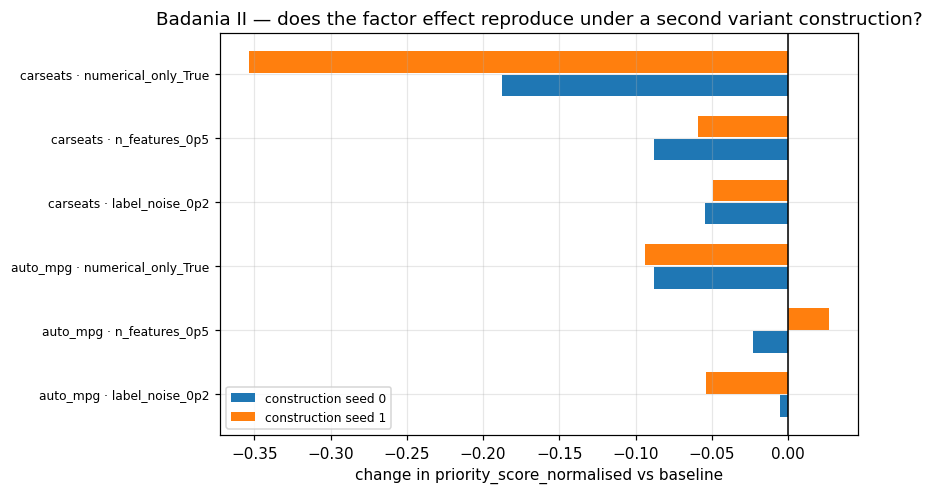

,cell,seed 0,seed 1
0,auto_mpg · label_noise_0p2,-0.0055,-0.0536
1,auto_mpg · n_features_0p5,-0.0231,0.0268
2,auto_mpg · numerical_only_True,-0.0879,-0.0939
3,carseats · label_noise_0p2,-0.0544,-0.0493
4,carseats · n_features_0p5,-0.0877,-0.0593
5,carseats · numerical_only_True,-0.1876,-0.3535


In [10]:
def plot_replication(metric="priority_score_normalised"):
    a = factor_effects("minlp", metric)
    if a.empty:
        print("no data"); return
    a["is_replicate"] = a["level"].eq("s1")
    a["key"] = np.where(a["is_replicate"],
                        a["dataset"] + " · " + a["factor"],
                        a["dataset"] + " · " + a["factor"] + "_" + a["level"])
    pairs = []
    for key, grp in a.groupby("key"):
        if grp["is_replicate"].nunique() == 2:
            pairs.append({"cell": key,
                          "seed 0": float(grp[~grp["is_replicate"]]["delta"].iloc[0]),
                          "seed 1": float(grp[grp["is_replicate"]]["delta"].iloc[0])})
    if not pairs:
        print("no replicated variants found"); return
    rep = pd.DataFrame(pairs)
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(rep) + 1.6))
    y = np.arange(len(rep))
    ax.barh(y - 0.18, rep["seed 0"], height=0.34, label="construction seed 0")
    ax.barh(y + 0.18, rep["seed 1"], height=0.34, label="construction seed 1")
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(rep["cell"], fontsize=8)
    ax.set_xlabel(f"change in {metric} vs baseline")
    ax.set_title("Badania II — does the factor effect reproduce under a second variant construction?")
    ax.legend(fontsize=8)
    plt.show()
    display(rep.round(4))

plot_replication()

## 5. Badania III — comparison with established methods

**The question.** How does the method compare with the counterfactual algorithms people actually
use?

**The design.** All methods solve the *identical* instance: same target, same tolerance, same
feasible region (derived from the priority set, so pinned features stay pinned and actionable ones
share the same box), same number of requested counterfactuals. The priority score is computed *post
hoc* for every method, including the seven that do not optimise it — that is the point of the
comparison.

Arms cover four regimes: free budget, a 2 000-evaluation cap, a harder target (−2σ), and releasing
the categorical columns for the baselines.

In [11]:
S3 = "study3_comparison"

def comparison_table(study_name=S3, regime="free budget", valid_only=True):
    df = study(study_name)
    suffix = {"free budget": None, "budget 2 000": "budget2k",
              "harder target (−2σ)": "hard_target", "categorical released": "cat"}[regime]
    if suffix is None:
        df = df[~df["arm"].str.contains("budget2k|hard_target|_cat")]
    else:
        df = df[df["arm"].str.endswith(suffix)]
    if df.empty:
        return pd.DataFrame()
    v = df[df["validity"] == True] if valid_only else df
    out = (df.groupby("arm")
             .agg(n=("sample_id", "size"), validity=("validity", "mean"),
                  model_rows=("model_rows", "mean"), time_s=("time_seconds", "mean"),
                  budget_fail=("error", lambda s: float((s == "budget_exceeded").mean())))
             .join(v.groupby("arm").agg(priority=("priority_score_normalised", "mean"),
                                        l1=("l1", "mean"), n_valid=("sample_id", "size")))
             .reset_index().sort_values("priority", ascending=False))
    return out

def plot_comparison(regime, metric, reference):
    tab = comparison_table(S3, regime)
    if tab.empty:
        print("no arms in this regime"); return
    display(Markdown(f"### {regime}"))
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(tab) + 1.6))
    colours = ["tab:blue" if a.startswith("minlp") else "0.7" for a in tab["arm"]]
    ax.barh(tab["arm"], tab[metric], color=colours)
    ax.invert_yaxis()
    ax.set_xlabel(metric)
    ax.set_title(f"Badania III — {regime} (blue = our method)")
    plt.show()
    display(tab.round(3))

    df = study(S3)
    arms = list(tab["arm"])
    if reference in arms:
        v = df[(df["validity"] == True) & (df["arm"].isin(arms))]
        rows = []
        for a in arms:
            if a == reference:
                continue
            r = stats.paired_comparison(v, a, reference, by="arm",
                                        value_col="priority_score_normalised")
            rows.append({"arm": a, "pairs": r.n_pairs, "delta_vs_ref": r.mean_delta,
                         "wins": r.wins_a, "losses": r.wins_b, "wilcoxon_p": r.wilcoxon_p,
                         "cliffs_delta": r.cliffs_delta, "magnitude": r.cliffs_magnitude})
        paired = pd.DataFrame(rows)
        if not paired.empty:
            paired["p_holm"] = stats.holm_correction(list(paired["wilcoxon_p"]))
            display(Markdown(f"**paired against `{reference}`** "
                             "(negative delta = that method is worse)"))
            display(paired.sort_values("delta_vs_ref").round(4))

def _cmp_ui():
    regimes = ["free budget", "budget 2 000", "harder target (−2σ)", "categorical released"]
    reg = widgets.Dropdown(options=regimes, description="regime:")
    met = widgets.Dropdown(options=["priority", "validity", "l1", "model_rows", "budget_fail"],
                           value="priority", description="metric:")
    ref = widgets.Text(value="minlp", description="reference:")
    out = widgets.interactive_output(plot_comparison,
                                     {"regime": reg, "metric": met, "reference": ref})
    display(widgets.VBox([widgets.HBox([reg, met, ref]), out]))

_cmp_ui()

**The results, and the one that matters most.**

*Free budget* — the method reaches 0.923 normalised priority at 96.7 % validity; every baseline lands
between 0.64 and 0.79. Paired, the baselines lose almost every comparison with large effect sizes.

*Budget-matched at 2 000 evaluations* — **the advantage disappears.** The method's validity collapses
from 0.967 to 0.567 (it cannot complete its Shapley + LP + SLSQP pipeline within that budget), and on
the instances where it does finish, the priority-weighted random search is *statistically better*
(+0.035, p = 0.009). Every other method is a statistical tie. **The superiority claim is a statement
about a high-budget regime and must be reported as such.**

*Harder target (−2σ)* — the advantage grows: baselines lose 0 of 78 and 0 of 79 paired comparisons,
Cliff's δ down to −0.90. Preference-aware search matters most where a counterfactual is hard to find.

*Categorical released* — letting the baselines switch categories buys them a little priority
(DiCE +0.028) but destroys their validity (DiCE 1.00 → 0.74, growing spheres 1.00 → 0.13, Wachter
0.57 → 0.10): snapping a one-hot state *after* optimisation moves the prediction out of the band.
Categorical handling has to live inside the search.

Reminder when reading the bars: priority is averaged over **valid** counterfactuals only. A method
that returns the instance unchanged (Nelder–Mead does) scores a high priority and zero validity.

In [12]:
def plot_paired_deltas(arm_a, arm_b, study_name=S3, metric="priority_score_normalised"):
    df = study(study_name)
    v = df[df["validity"] == True]
    merged = stats.paired_frame(v, arm_a, arm_b, value_col=metric, by="arm")
    if merged.empty:
        print("no comparable pairs"); return
    res = stats.paired_comparison(v, arm_a, arm_b, value_col=metric, by="arm")
    d = np.sort(merged["delta"].to_numpy())
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(np.arange(d.size), d, color=["tab:green" if x > 0 else "crimson" for x in d])
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("paired instance (sorted)")
    ax.set_ylabel(f"{arm_a} − {arm_b}")
    ax.set_title(f"{res.wins_a} wins / {res.wins_b} losses · mean Δ = {res.mean_delta:+.3f} · "
                 f"Wilcoxon p = {res.wilcoxon_p:.2e} · Cliff's δ = {res.cliffs_delta:+.2f} "
                 f"({res.cliffs_magnitude})", fontsize=10)
    plt.show()

def _pair_ui():
    df = study(S3)
    arms = sorted(df["arm"].unique())
    a = widgets.Dropdown(options=arms, value="minlp", description="method A:")
    b = widgets.Dropdown(options=arms, value="dice" if "dice" in arms else arms[0],
                         description="method B:")
    out = widgets.interactive_output(plot_paired_deltas, {"arm_a": a, "arm_b": b})
    display(widgets.VBox([widgets.HBox([a, b]), out]))

_pair_ui()

**This is the figure that carries a comparison claim in an article.** Each bar is one instance
solved by both methods; green means A won. Method-level averages hide the fact that methods succeed
on different subsets of instances, which is why every statistical statement in this project is
paired.

## 6. Exporting figures for the article

Every plotting function above ends with `plt.show()`. To export, call it inside the helper below —
it captures the current figure and writes a 200 dpi PNG into `paper/figures/`.

In [ ]:
def export(plot_call, name):
    """Run a plotting call and save whatever figure it produced."""
    plot_call()
    fig = plt.gcf()
    return save_fig(fig, name)

# Examples — uncomment what you need:
# export(lambda: plot_priority_feature("auto_mpg", "medium", 1, "weight", True, False),
#        "priority_curve_auto_mpg_weight")
# export(lambda: plot_budget_pareto("study3_comparison", True, True), "cost_vs_quality")
# export(lambda: plot_factor_forest("minlp", "priority_score_normalised", True, 0.05),
#        "factor_effects_minlp")
# export(lambda: plot_paired_deltas("minlp", "dice"), "paired_minlp_vs_dice")
print("figures directory:", FIGURES_DIR)

## 7. Extending this notebook

The notebook is deliberately generic; adding new material should not require editing the plotting
code.

**A new metric.** Any column present in a study's `counterfactuals.csv` appears automatically in the
metric dropdowns — add the column in `paper/common/execute.py`, re-run the study, and it shows up.

**A new dataset.** Prepare it (`data_setup.py`), train a model (`model_setup.py`), add a scenario
spec to `priority_sets.py`. It then appears in every dataset dropdown here, and can be listed in any
study config.

**A new priority set.** Add it under `PRIORITY_SETS[dataset]`; the priority widgets pick it up with
no further change. Check it with `priority_sets_check.py` before running a study.

**A new study.** Create `paper/<study_name>/config.yaml` and run
`python -m explainit.experiments.paper.run_study --config …`. It appears in the state table, the
study dropdowns and the cost-vs-quality plot automatically.

**A new method.** Register it in the priority-methods registry or the standard-methods registry; the
bridge exposes both under one name space, so a study config can simply name it.

**Useful commands**

```bash
python -m explainit.experiments.paper.status                         # what is running / complete
python -m explainit.experiments.paper.run_study --config <cfg>       # run or resume a study
python -m explainit.experiments.paper.analyse_study --study <name> --by arm --reference minlp
python -m explainit.experiments.paper.analyse_factors --study study2_factors --method minlp
python -m explainit.experiments.continuous_minlp.priority_sets_check --datasets <ds>
```

The narrative write-up of the design and all findings lives in `EXPERIMENTS.md` next to this
notebook.